⚠️ **CORRECTION** — This notebook contains a proposed solution for `TP_hyperparameter_tuning.ipynb`. It is meant to be pedagogical: it favors clarity over finding "the best model", and shows what is at stake when training a model and dealing with parameter tuning and deployment.

# Partie 1 : Theory of machine learning (~45 mn)

We will use the document [theoretical_basis_of_ml.pdf](./theoretical_basis_of_ml.pdf). It shows that all machine learning problem can be rewritten as an optimisation problem
$$
\underset{g \in\mathcal{G}}{\argmin}\space \frac{1}{n} \sum_{i=1}^{n}l(Y_i, g(X_i))
$$

There are many different ways to optimise the search of a best model. We try to give insights and intuitions of which one will likely perform better in different situations (cf. document).

#### Option 1 - Reduce the variance : Optimise the search "inside" $\mathcal{G}$

- **Change the optimizer** method to make convergence faster / more precise, takin ginto account the loss function
- **Change the loss** $l$ to a "more regular" or "more convex" function (e.g. logit / softmax instead of error rate) to make convergence easier  
- **Reformat features** to help convergence : for instance, discretizing continuous features may help by reducing the $\mathcal{X}$ space  
- **Add regularisation hyperparameter** (e.g. l1 - lasso regression, l2 - ridge regression) to "smoothen" the $\mathcal{G}$ space 
- Convexify the loss by **using bagging estimator**: 
The key idea is that if we have $C_1, ..., C_T$ classifiers with the same distribution of mean $m$ and variance $\sigma^2$, then we can consider the average $C=\frac{1}{T}\sum_{k=1}^{T}C_k$. We have :
    - $\mathbb{E}[C]=\frac{1}{T}\mathbb{E}[\sum_{k=1}^{T}C_k]=\frac{1}{T}\sum_{k=1}^{T}\mathbb{E}[C_k]=\frac{T}{T}m=m$
    - $\mathbb{V}[C]=\frac{1}{T^2}\mathbb{V}[\sum_{k=1}^{T^2}C_k]=\frac{1}{T^2}(\sum_{k=1}^{T}\mathbb{V}[C_k]+2 \sum_{1 \leq i < j\leq T} Cov(C_i, C_j))=\frac{\sigma^2}{T} + \frac{2}{T} \sum_{1 \leq i < j\leq T} Cov(C_i, C_j)$ so if the correlation of the $C_k$ is "low" (which can be achieved by randomly removing rows and columns in the original dataset, or by downsampling), the variance is greatly reduced. In the limit case where they are independant, the variance is divided by T while the bias stay the same. For this reason it is highly recommended to create a bagged estimator when the estimator is unstable.
- **Resampling** (down, up, SMOTE) an unbalanced dataset to help convergence. Notice that it changes the distribution, instead of estimating $\mathbb{E}[Y|X]$ we estimate $\mathbb{E}[Y_{resampled}|X]$, but $\mathbb{E}[\mathbb{E}[Y|X]]=\mathbb{E}[Y] \neq \mathbb{E}[Y_{resampled}]$ so all estimated probabilities are wrong. 
    - This is *not an issue if we want to rank* because the order is preserved. 
    - This is *a big issue if the exact level of probability matter*, for instance to evalate an insurance premium because we will over or underestimating the risk of claims would lead to a wrong premium.

#### Option 2-  Reduce the bias: Optimise the search globally
- **Transform the features** to modify $\mathcal{G}$: for instance, if you use powered features or create product between features with a linear model, you now allow to search in a polynomial space. Notice that it does NOT create information, and it is not useful for all algorithm : for a tree a monotonic transformation of a continuous feature will not help. 
- Explore new spaces $\mathcal{G}$ by **changing algorithm** (e.g. GLM, random forest, SVM, gradient boosted trees...)
- **Explore new spaces $\mathcal{G}$ by changing hyperparameter** of a given family of algorithm : for instance if you are using boosted trees with fixed tree depth, you can change the tree depth and retrain to see if this new class $\mathcal{G}$ offer better predictive performance. This process is reffered to as **finetuning hyperparameters**. ⚠️Beware:  
    - **Parametric algorithms** (e.g GLM) make assumptions about the underlying distribution (the relation between X and Y is linear), which makes them **more underfitting prone** and makes more important the work on the features spaces $\mathcal{X}$ to redefine a good underlying space $\mathcal{G}$.
    - On the opposite **non parametric algorithm** like tree based methods or neural network makes very little assumptions on the underlying distribution. It makes them much more prone to overfitting, but also able to fit very coomplex distribution and less biased in many situations. Regularisation is very important for these kind of algorithms.
-  Change $\mathcal{X}$ : **Add new features** to your dataset gives more information, hence the conditional expectation of Y given X is necessarily greater. It has often much more impact on the end result than changing the space $\mathcal{G}$. You can try for instance different aggregates on different time periods, look for new data sources...

#### Option 3 - Redefine the problem to make it easier

- **Change the loss function $l$** : Depending on the problem, you may have different optima with different loss functions. Some metrics tend to flattten quickly (e.g. AUC is insenstitive to the absolute value of probabilities if the order of instances remain unchanged : it tends to "plateau" quickly while the convergence is not fully finished). It is recommended to **use several evalution metrics** to detect these different optima.
- For classification problems, it can be useful to **finetune the threshold** because many metrics are very threshold sensitive (e.g. precision, recall, accuracy) and the default 50% threshold may be *very* inadequate for your problem. For instance for an imbalanced dataset with 1% fraud, a 5% fraud prediction may be very high regarding the rest of the data, and worth investigating.
- **Evaluate differently** : When data are time sensitive, the distribution can change over time which violates our hypothesis. It is strongly recommended to create a train / test split  not at random but "time based" (i.e. train on one year and test on the following year) to detect these distribution shift (e.g. claims cost increase due to inflation).
- **Change $\mathcal{Y}$** : A problem can be framed in several way, which impact the underlying modelling hypothesis. For instance, the risk to churn (terminate your contract) will be identified byy differetn features if we predict churn in 1 month (likely "hot data" like recent claims, call to the call center, bad NPS, people with recent preimums increase...) vs 1 year (likely "cold data" like population with "above the market" premiums).

💡**It is recommended to use an AI (Copilot, ChatGPT...) in all the notebook to get help with the syntax, understand code...**

# Partie 2 : Create baselines model (~2h)

## 📝 Exercise 1 : load and explore the dataset ``ec_dde_tpe_2019_2023.pkl``. This dataset contains data for house insurance claims costs. 

Instructions : Use a copilot prompt to explore the dataset. You can for instance:
- Load the dataset from the path data/01_raw/ec_dde_tpe.pkl
- Display the first 5 rows of the dataset
- Display the last 5 rows of the dataset
- Display the shape of the dataset
- Display the columns of the dataset
- Display the data types of the columns
- Display the number of missing values in each column
- quickly plot / give distribution / number of missing values of the variables

In [1]:
from pathlib import Path

import pandas as pd

claims_data_mrh = pd.read_pickle(
    Path().cwd().parent / "data" / "01_raw" / "ec_dde_tpe_2019_2023.pkl"
)
claims_data_mrh["DATE_SURVENANCE"] = pd.to_datetime(claims_data_mrh["DATE_SURVENANCE"])
claims_data_mrh["DATE_NAISSANCE"] = pd.to_datetime(claims_data_mrh["DATE_NAISSANCE"])
claims_data_mrh["DATE_DECLARATION"] = pd.to_datetime(claims_data_mrh["DATE_DECLARATION"])
claims_data_mrh["YEAR_SURVENANCE"] = claims_data_mrh["DATE_SURVENANCE"].dt.year

claims_data_mrh.head()

,CLE,DATE_NAISSANCE,CODE_POSTAL,PRIMES,MOBILIER,OBJETS_VALEUR,ZONIER,USAGE,NOMBRE_PIECES,NOMBRE_ETAGES,SURFACE_HAB,EXTENSION_HAB,SURFACE_AUTRE,FORMULE,DATE_SURVENANCE,DATE_DECLARATION,GARANTIE,NB_SINISTRES,CHARGE_SINISTRES,YEAR_SURVENANCE
0,0,1988-09-04,63670,245.44,43683.66,4368.26,2,RESIDENCE_PRINCIPALE,[3.0-4.0[,<NA>,[100.0-115.0[,0.0,[0.0-1.0[,TOUT_RISQUE,2020-07-21,2020-08-09,DDE,1.0,750.20,2020
1,1,1984-08-29,64121,334.55,42859.44,4285.84,2,RESIDENCE_PRINCIPALE,[3.0-4.0[,<NA>,[66.0-78.0[,0.0,[0.0-1.0[,TOUT_RISQUE,2021-03-17,2021-03-29,DDE,1.0,217.72,2021
2,2,1985-08-15,83300,405.46,53058.39,5305.53,5,RESIDENCE_PRINCIPALE,[4.0-5.0[,<NA>,[115.0-140.0[,0.0,[0.0-1.0[,TOUT_RISQUE,2019-11-11,2019-11-22,DDE,1.0,5103.54,2019
3,3,1956-09-17,75012,208.95,42447.33,4244.63,6,RESIDENCE_PRINCIPALE,[3.0-4.0[,[3.0-670.0[,[115.0-140.0[,0.0,[0.0-1.0[,TOUT_RISQUE,2020-03-27,2020-05-08,DDE,1.0,220.71,2020
4,4,1960-03-19,63000,94.60,0.00,0.00,2,RESIDENCE_SECONDAIRE,[2.0-3.0[,<NA>,[66.0-78.0[,0.0,[0.0-1.0[,CONFORT,2020-07-30,2020-08-23,DDE,1.0,205.89,2020


In [2]:
claims_data_mrh.tail()

,CLE,DATE_NAISSANCE,CODE_POSTAL,PRIMES,MOBILIER,OBJETS_VALEUR,ZONIER,USAGE,NOMBRE_PIECES,NOMBRE_ETAGES,SURFACE_HAB,EXTENSION_HAB,SURFACE_AUTRE,FORMULE,DATE_SURVENANCE,DATE_DECLARATION,GARANTIE,NB_SINISTRES,CHARGE_SINISTRES,YEAR_SURVENANCE
14941,14941,1989-10-25,59500,224.47,42447.33,4244.63,5,RESIDENCE_PRINCIPALE,[3.0-4.0[,[2.0-3.0[,[66.0-78.0[,0.0,[0.0-1.0[,TOUT_RISQUE,2023-12-13,2024-07-01,DDE,1.0,596.81,2023
14944,14944,1995-02-16,83200,218.69,31835.24,3183.73,5,RESIDENCE_PRINCIPALE,[2.0-3.0[,[0.0-1.0[,[52.0-66.0[,0.0,[0.0-1.0[,TOUT_RISQUE,2023-12-18,2024-03-05,DDE,1.0,574.78,2023
14945,14945,1955-10-16,64100,83.91,7155.00,NaN,2,RESIDENCE_PRINCIPALE,[1.0-2.0[,[0.0-1.0[,[16.0-36.0[,0.0,[0.0-1.0[,CONFORT,2023-12-10,2024-01-30,DDE,1.0,180.52,2023
14962,14962,1998-05-14,57390,203.80,11126.16,NaN,2,AUTRE,[5.0-6.0[,<NA>,[140.0-557.0[,0.0,[0.0-1.0[,STANDARD,2023-12-22,2024-01-05,DDE,1.0,747.75,2023
14983,14983,1985-11-12,56100,498.06,108178.35,10818.15,3,RESIDENCE_PRINCIPALE,[6.0-23.0[,<NA>,[140.0-557.0[,0.0,[0.0-1.0[,TOUT_RISQUE,2023-11-01,2023-11-24,TEMPETE,1.0,4537.95,2023


In [3]:
print("shape:", claims_data_mrh.shape)
print("columns:", claims_data_mrh.columns.tolist())
claims_data_mrh.dtypes

shape: (13235, 20)
columns: ['CLE', 'DATE_NAISSANCE', 'CODE_POSTAL', 'PRIMES', 'MOBILIER', 'OBJETS_VALEUR', 'ZONIER', 'USAGE', 'NOMBRE_PIECES', 'NOMBRE_ETAGES', 'SURFACE_HAB', 'EXTENSION_HAB', 'SURFACE_AUTRE', 'FORMULE', 'DATE_SURVENANCE', 'DATE_DECLARATION', 'GARANTIE', 'NB_SINISTRES', 'CHARGE_SINISTRES', 'YEAR_SURVENANCE']


CLE                          int64
DATE_NAISSANCE      datetime64[ns]
CODE_POSTAL                 object
PRIMES                     float64
MOBILIER                   float64
OBJETS_VALEUR              float64
ZONIER                       int64
USAGE                       object
NOMBRE_PIECES               object
NOMBRE_ETAGES               object
SURFACE_HAB                 object
EXTENSION_HAB               object
SURFACE_AUTRE               object
FORMULE                     object
DATE_SURVENANCE     datetime64[ns]
DATE_DECLARATION    datetime64[ns]
GARANTIE                    object
NB_SINISTRES               float64
CHARGE_SINISTRES           float64
YEAR_SURVENANCE              int32
dtype: object

In [4]:
missing_values = claims_data_mrh.isna().sum().sort_values(ascending=False)
missing_values

NOMBRE_ETAGES       4715
OBJETS_VALEUR        484
DATE_NAISSANCE       294
EXTENSION_HAB         58
SURFACE_AUTRE         46
SURFACE_HAB           25
CODE_POSTAL           16
CLE                    0
PRIMES                 0
USAGE                  0
MOBILIER               0
ZONIER                 0
NOMBRE_PIECES          0
FORMULE                0
DATE_SURVENANCE        0
DATE_DECLARATION       0
GARANTIE               0
NB_SINISTRES           0
CHARGE_SINISTRES       0
YEAR_SURVENANCE        0
dtype: int64

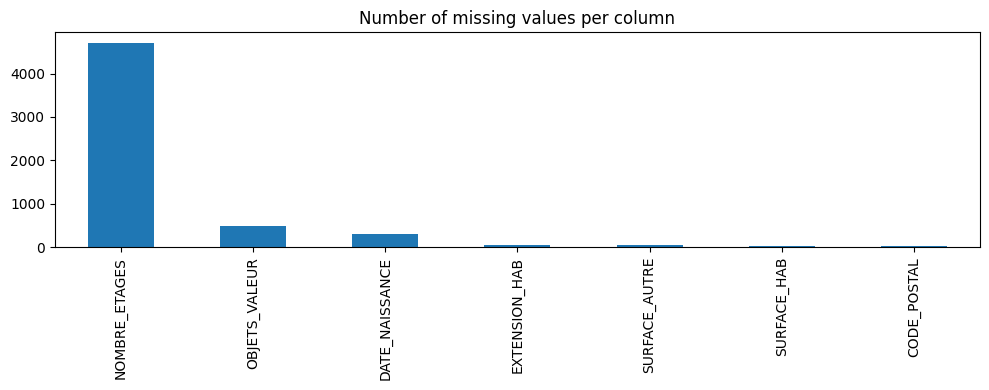

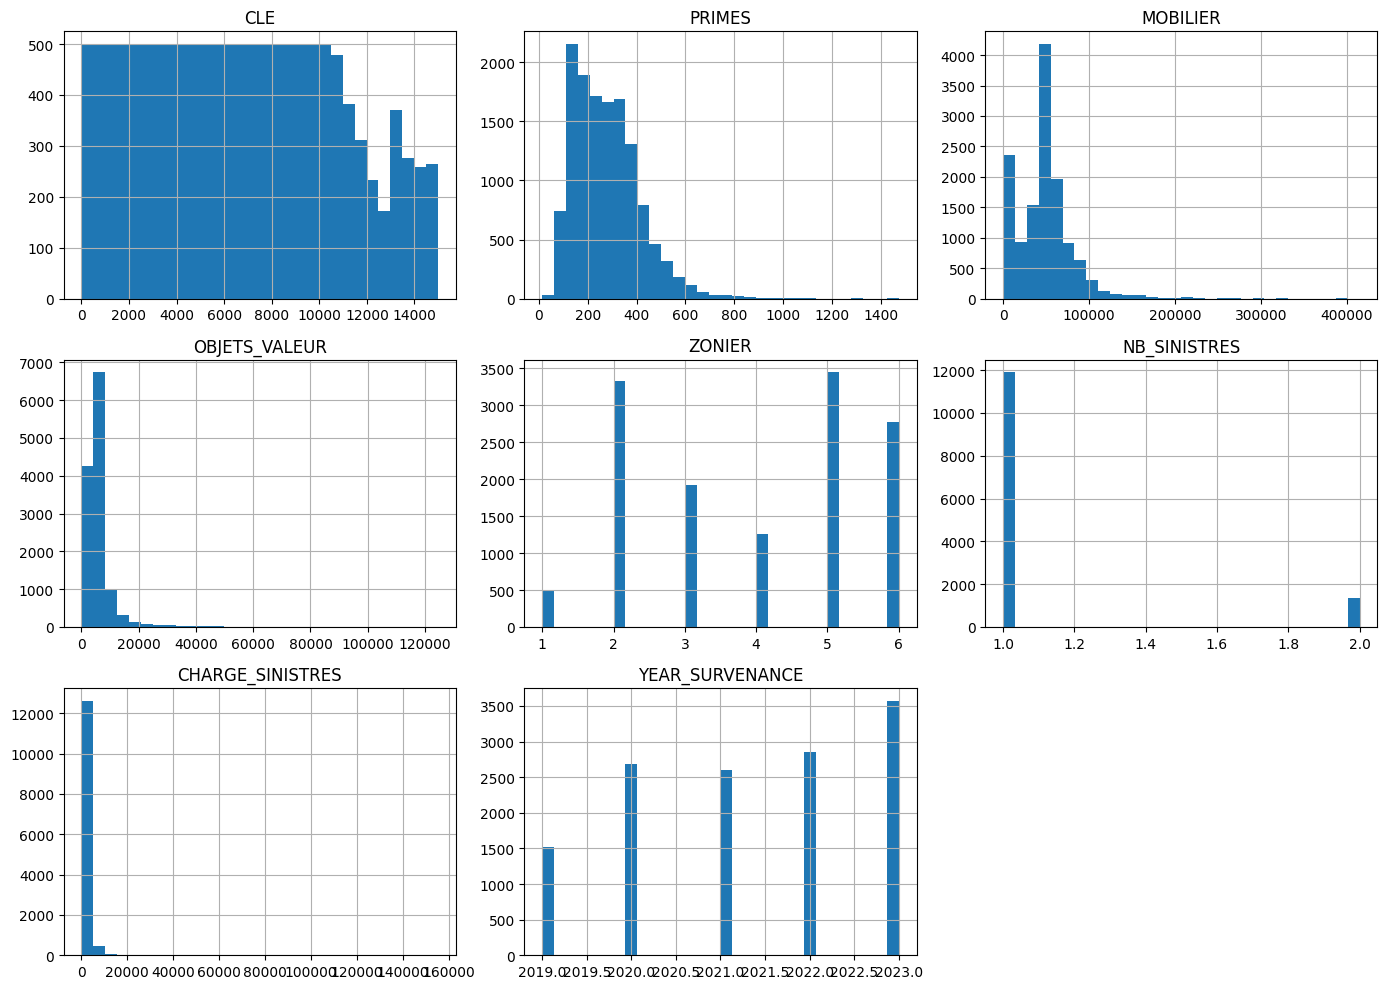

In [5]:
import matplotlib.pyplot as plt

claims_data_mrh.describe(include="all")

missing_values[missing_values > 0].plot(
    kind="bar", figsize=(10, 4), title="Number of missing values per column"
)
plt.tight_layout()
plt.show()

claims_data_mrh.select_dtypes("number").hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

💡**Copilot prompt example :**
> My claims_data_mrh dataframe has the following keys
> CLE DATE_NAISSANCE PRIMES MOBILIER OBJETS_VALEUR ZONIER DATE_SURVENANCE DATE_DECLARATION NB_SINISTRES CHARGE_SINISTRES
> I want to plot the number of claims per year with a bar chart grouped by GARANTIE

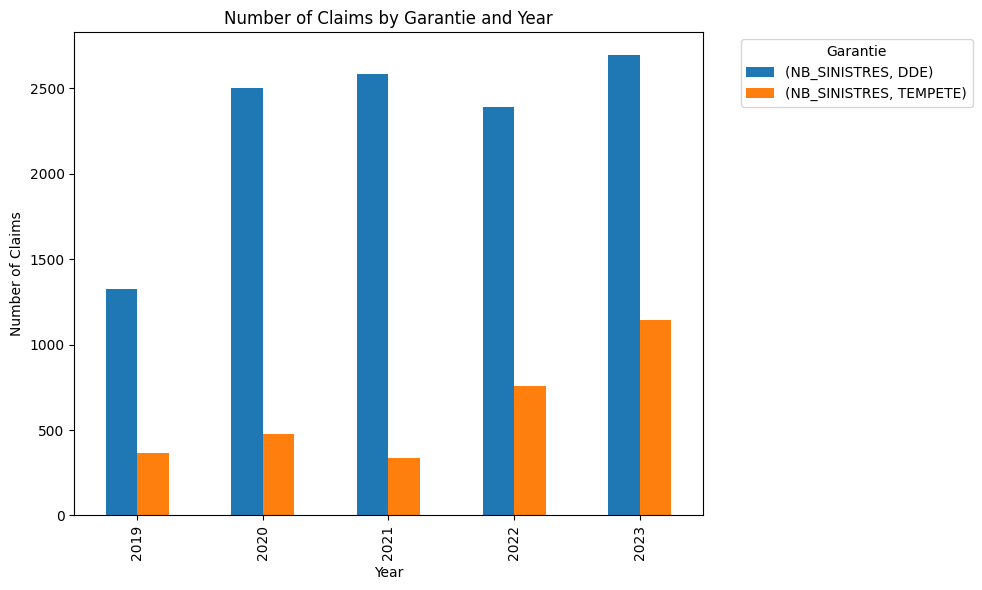

In [6]:
claims_by_year_garantie = (
    claims_data_mrh.groupby(["YEAR_SURVENANCE", "GARANTIE"])[["NB_SINISTRES"]]
    .sum()
    .unstack()
)

claims_by_year_garantie.plot(
    kind="bar",
    stacked=False,
    figsize=(10, 6),
    title="Number of Claims by Garantie and Year",
)
plt.xlabel("Year")
plt.ylabel("Number of Claims")
plt.legend(title="Garantie", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

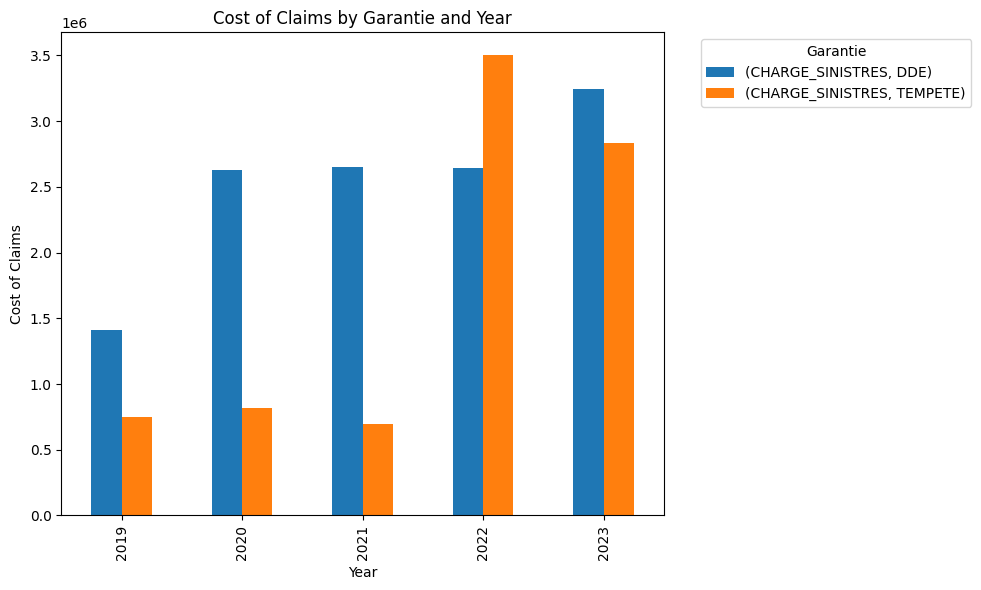

In [7]:
amount_by_year_garantie = (
    claims_data_mrh.groupby(["YEAR_SURVENANCE", "GARANTIE"])[["CHARGE_SINISTRES"]]
    .sum()
    .unstack()
)

amount_by_year_garantie.plot(
    kind="bar",
    stacked=False,
    figsize=(10, 6),
    title="Cost of Claims by Garantie and Year",
)
plt.xlabel("Year")
plt.ylabel("Cost of Claims")
plt.legend(title="Garantie", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 🤔 Take a step back and comment on the data quality, and some feature transformation that will be needed. We want to predict the "CHARGE_SINISTRES" variable. 

- We likely need to distinguish between DDE and TEMPETE!
- some variables have null values which are unrealistic ( MOBILIER,  OBJETS_VALEUR...)
- somes variables are very correlated
- It does not make sense to predict the number of claims, because we don't have the "no claims" data in our dataset
- Some features will likely not be available at inference time, so you will need to drop them from the model
- features to remove: CLE, DATE_NAISSANCE, DATE_DECLARATION, DATE_SURVENANCE, GARANTIE, YEAR_SURVENANCE
- feature to transform : DATE_NAISSANCE-> AGE ; CHARGE_SINISTRES -> COUT_UNITAIRE; CODE_POSTAL -> DEPARTMENT

**Correction notes:**
- `NB_SINISTRES` is also unusable as a feature at inference time (it leaks the label, since `COUT_UNITAIRE = CHARGE_SINISTRES / NB_SINISTRES`).
- `OBJETS_VALEUR` is ~100% correlated with `MOBILIER`, so it can be dropped without losing information.
- `EXTENSION_HAB` should be turned into a boolean `HAS_EXTENSION` rather than used as a raw (mostly missing) numeric column.

💡 **For the sake of simplicity and to keep on time constraints, we will remove some problematic variables and not impute / deal with missing data or outliers for now.** 

## 📝 Exercise 2 - Prepare the features
Instructions: 
- create variable "AGE"
- create variable "DEPARTMENT"
- create variable "COUT_UNITAIRE" as a label
- create_variable "HAS_EXTENSION"
- plot an histogram of "COUT_UNITAIRE" to check the distribution

Try to explain why we are doing these transformations!

In [9]:
import numpy as np

# AGE : year of the claim minus year of birth
claims_data_mrh["AGE"] = (
    claims_data_mrh["DATE_SURVENANCE"].dt.year - claims_data_mrh["DATE_NAISSANCE"].dt.year
)

# DEPARTEMENT : first 2 digits of the postal code (imputation of missing/special codes to -1 is a simplification, discussed below)
claims_data_mrh["DEPARTEMENT"] = (
    pd.to_numeric(claims_data_mrh["CODE_POSTAL"].astype(str).str[:2], errors="coerce")
    .fillna(-1)
    .astype(int)
)

# COUT_UNITAIRE : the label we want to predict (average cost per claim)
claims_data_mrh["COUT_UNITAIRE"] = (
    claims_data_mrh["CHARGE_SINISTRES"] / claims_data_mrh["NB_SINISTRES"]
)

# HAS_EXTENSION : boolean flag instead of a mostly-missing numeric column
claims_data_mrh["HAS_EXTENSION"] = (
    claims_data_mrh["EXTENSION_HAB"].fillna(0).astype(float) > 0
)

claims_data_mrh[["AGE", "DEPARTEMENT", "COUT_UNITAIRE", "HAS_EXTENSION"]].head()

,AGE,DEPARTEMENT,COUT_UNITAIRE,HAS_EXTENSION
0,32.0,63,750.20,False
1,37.0,64,217.72,False
2,34.0,83,5103.54,False
3,64.0,75,220.71,False
4,60.0,63,205.89,False


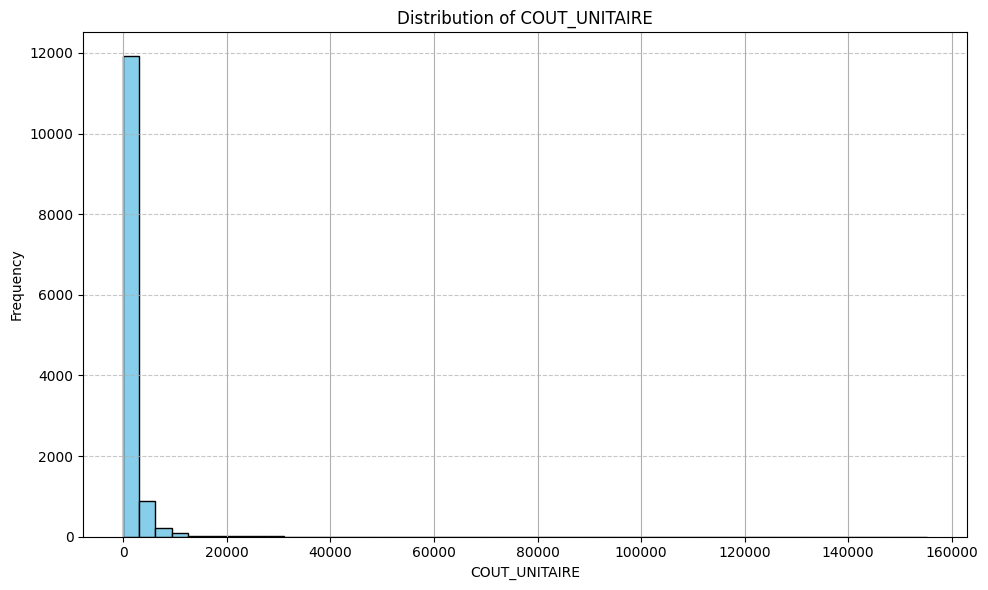

In [10]:
plt.figure(figsize=(10, 6))
claims_data_mrh["COUT_UNITAIRE"].hist(bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of COUT_UNITAIRE")
plt.xlabel("COUT_UNITAIRE")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# The distribution is strictly positive, right-skewed with a heavy tail -> a Gamma
# distribution is a much better assumption than a Gaussian one for this target.

## 📝 Exercise 3 - Train a baseline model

We are modelling a variable with stricly positive value and huge tail value. Gamma regression is a good fit for such target variable.  

Instructions:
- drop unused features
- for categorical values:
    - impute categorical value with the most frequent value
    - one hot encode the categorical variables (ensure you let 1 level out to avoid perfect correlations of features)
- for categorical values:
    - impute with mean 

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

# drop rows with missing/infinite COUT_UNITAIRE (no information loss, but worth checking!)
print(claims_data_mrh.shape)
claims_data_mrh = claims_data_mrh.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["COUT_UNITAIRE"]
)
print(claims_data_mrh.shape)

# Define features (X) and target (y) : drop columns unavailable at inference time or that leak the label
X = claims_data_mrh.drop(
    columns=[
        "CLE",
        "DATE_NAISSANCE",
        "DATE_SURVENANCE",
        "DATE_DECLARATION",
        "CODE_POSTAL",
        "COUT_UNITAIRE",
        "YEAR_SURVENANCE",
        "EXTENSION_HAB",
        "OBJETS_VALEUR",  # 100% correlated to value MOBILIER
        "CHARGE_SINISTRES",
        "NB_SINISTRES",
    ]
)
y = claims_data_mrh["COUT_UNITAIRE"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

categorical_pipeline = make_pipeline(
    SimpleImputer(missing_values=pd.NA, strategy="most_frequent"),
    OneHotEncoder(sparse_output=False, handle_unknown="error", drop="first"),
)

# numeric columns (e.g. AGE) use plain float NaN, not the pd.NA sentinel used by object columns
numeric_pipeline = make_pipeline(SimpleImputer(missing_values=np.nan, strategy="mean"))

column_transformer = ColumnTransformer(
    (
        ("numerical", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ),
    verbose_feature_names_out=False,
).set_output(transform="pandas")

column_transformer.fit(X_train)
X_train_transformed = column_transformer.transform(X_train)
X_test_transformed = column_transformer.transform(X_test)

(13235, 24)
(13235, 24)


In [15]:
X_train_transformed.head()

,PRIMES,MOBILIER,ZONIER,AGE,DEPARTEMENT,HAS_EXTENSION,USAGE_PROFESSIONNEL,USAGE_RESIDENCE_PRINCIPALE,USAGE_RESIDENCE_SECONDAIRE,NOMBRE_PIECES_[1.0-2.0[,...,SURFACE_HAB_[16.0-36.0[,SURFACE_HAB_[36.0-52.0[,SURFACE_HAB_[52.0-66.0[,SURFACE_HAB_[66.0-78.0[,SURFACE_HAB_[78.0-89.0[,SURFACE_HAB_[89.0-100.0[,SURFACE_AUTRE_[1.0-15.0[,FORMULE_STANDARD,FORMULE_TOUT_RISQUE,GARANTIE_TEMPETE
12557,218.04,21841.30,5.0,58.0,83.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3379,132.55,11023.14,4.0,63.0,38.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3921,274.71,65524.96,2.0,35.0,64.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1056,272.42,66761.28,2.0,58.0,50.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1146,101.00,34384.44,2.0,35.0,64.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


💡 **For reproducibility, use the make_pipeline and the ColumnTransformer API**. You will thank me later in the notebook ;) Please rewrite previous cell if you did not.

In [16]:
from sklearn.linear_model import GammaRegressor

gamma_model = GammaRegressor(fit_intercept=True, solver="lbfgs", max_iter=10_000)
gamma_model.fit(X_train_transformed, y_train)

coefficients = pd.DataFrame(
    {"Feature": X_train_transformed.columns, "Coefficient": gamma_model.coef_}
).sort_values(by="Coefficient", ascending=False)
coefficients

c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\sklearn\linear_model\_linear_loss.py:356: RuntimeWarning: invalid value encountered in matmul
  X_grad = X.T @ grad_pointwise


,Feature,Coefficient
31,GARANTIE_TEMPETE,0.021308
21,SURFACE_HAB_[140.0-557.0[,0.005586
13,NOMBRE_PIECES_[5.0-6.0[,0.004439
0,PRIMES,0.004217
20,SURFACE_HAB_[115.0-140.0[,0.003925
14,NOMBRE_PIECES_[6.0-23.0[,0.001999
8,USAGE_RESIDENCE_SECONDAIRE,0.001777
12,NOMBRE_PIECES_[4.0-5.0[,0.001762
5,HAS_EXTENSION,0.001560
19,SURFACE_HAB_[100.0-115.0[,0.000629


In [18]:
y_pred_train = pd.DataFrame(
    gamma_model.predict(X_train_transformed),
    index=X_train.index,
    columns=["pred_COUT_UNITAIRE"],
)
y_pred_test = pd.DataFrame(
    gamma_model.predict(X_test_transformed),
    index=X_test.index,
    columns=["pred_COUT_UNITAIRE"],
)

print(y_train.mean(), y_pred_train.mean())
print(y_test.mean(), y_pred_test.mean())

1559.3810266339253 pred_COUT_UNITAIRE    1615.44654
dtype: float64
1470.1547733282962 pred_COUT_UNITAIRE    1628.318443
dtype: float64


In [19]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred_test)
rmse = root_mean_squared_error(y_test, y_pred_test)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")  # This is terrible! close to a 100% error rate

Mean Absolute Error (MAE): 1266.5437992135633
Root Mean Squared Error (RMSE): 2719.750410596905


#### 🤔Take a step back and discuss the results
- This is quite a bad model : the rmse is of the same order of magnitude than the mean, so it is a 100% error rate!
- The prediction on test is reasonnably close to the average, which shows good convergence. 

## 📝 Exercise 4 -  Train an xgboost regressor

- Introduction to the algorithm : https://speakerd.s3.amazonaws.com/presentations/5c6dab45648344208185d2b1ab4fdc95/XGBoost-Newest.pdf
- Instructions:
    - Train a XGBRegressor from the xgboost library
    - predict on test dataset
    - evaluate rmse


#### 💡 Hints on the model:
- ``n_estimators``: the number of trees to build. The more trees, the better the model, but also the longer it takes to train and th greter risk of overffitting.. A good proxy is to take n_estimators in [1/eta; 10/eta] to ensure convergence is finished
- the learning_rate ``eta`` control the convergence speed : witht the right amount of trees, we should get almost the same minimum, hopefeully reach after 1/eta iterations.
- ``max_depth`` : the complexity of the trees. The more complex the trees, the less bias but the more variance at ach step. A good proxy is to take max_depth in [4,12], unless there are very complex relationships between columns, and a lot of columns
- always put a ``seed`` to make result reproducible.
- ``colsample_bytree``: the fraction of features to use for each tree. A good proxy is to take colsample_bytree in [0.5, 1]. The more columns the more we need to reduce colsample by tree to make trees independant and reduce variance. For some rare case with sparse data (e.g. nLP with bag of words), we can use colsample_bytree <0.5 to get a better result.
- ``subsample``: the fraction of rows to use for each tree. A good proxy is to take subsample in [0.5, 1]. The more rows the more we need to reduce subsample to make trees independant and reduce variance. It is also very usefl when the class is imbalanced
- ``min_child_weight``: the minimum sum of weights of all observations required in a child. For L2 loss this is the number of observations in an node. For L1 loss this is the sum of the absolute values of the observations. A good proxy is to take min_child_weight in [1,10] unless the  class is imbalanced. If max_depth is small, this is "naturally" limited becasue there are more observations per node

#### 💡Hints on the fitting procedure:
- **Early stopping is absolutely mandatory**, else the model will train all estimators nomatter if it is overfitting or not. The number of trees should not be estimated, but fitted with early_stopping. 
If early stopping has not be triggered, retrain with a higher number of trees.
- for NA,we **could avoid imputing** and let xgboost impute NA as a category; it chooses the best path in the branch for na
- imputing by a numeric out of range value (e;g. 1 for all positive) may makes sense because we would interpret all -1 as NA and quantifi its specific impact
- for categorical features, ``TargetEncoding`` or ``OrdinalEncoding`` are much better because you keep readibility (no multiple columns due to one hot encoding), but it is also possible to let xgboost discretize automatically

In [20]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,  # Number of trees
    max_depth=6,  # Maximum depth of trees
    learning_rate=0.01,  # Learning rate
    random_state=42,  # Random seed
    colsample_bytree=1,
    subsample=1,
    min_child_weight=None,
    early_stopping_rounds=20,
    enable_categorical=True,
)

# xgboost can natively handle categorical features if declared as "category" dtype
for col in X_train.select_dtypes(include=["object"]).columns:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

y_pred_train_xgb = pd.DataFrame(
    xgb_model.predict(X_train),
    index=X_train.index,
    columns=["pred_COUT_UNITAIRE"],
)
y_pred_test_xgb = pd.DataFrame(
    xgb_model.predict(X_test),
    index=X_test.index,
    columns=["pred_COUT_UNITAIRE"],
)

print(y_train.mean(), y_pred_train_xgb.mean())
print(y_test.mean(), y_pred_test_xgb.mean())

mae_xgb = mean_absolute_error(y_test, y_pred_test_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_test_xgb)
print(f"Mean Absolute Error (MAE): {mae_xgb}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb}")
# Much better than the GLM, but still a large relative error - could we reintroduce
# some dropped features (e.g. HAS_EXTENSION, DEPARTEMENT)?

[0]	validation_0-rmse:2467.00109
[1]	validation_0-rmse:2464.16544
[2]	validation_0-rmse:2461.58412
[3]	validation_0-rmse:2458.97918
[4]	validation_0-rmse:2456.60105
[5]	validation_0-rmse:2453.87351
[6]	validation_0-rmse:2451.59870
[7]	validation_0-rmse:2449.31134
[8]	validation_0-rmse:2446.98649
[9]	validation_0-rmse:2444.85477
[10]	validation_0-rmse:2442.74988
[11]	validation_0-rmse:2440.79629
[12]	validation_0-rmse:2438.99281
[13]	validation_0-rmse:2437.04508
[14]	validation_0-rmse:2435.46963
[15]	validation_0-rmse:2433.80443
[16]	validation_0-rmse:2432.00975
[17]	validation_0-rmse:2430.50729
[18]	validation_0-rmse:2429.19233
[19]	validation_0-rmse:2427.65883
[20]	validation_0-rmse:2426.31462
[21]	validation_0-rmse:2424.95558
[22]	validation_0-rmse:2424.13414
[23]	validation_0-rmse:2422.73388
[24]	validation_0-rmse:2421.95322
[25]	validation_0-rmse:2420.92511
[26]	validation_0-rmse:2419.68495
[27]	validation_0-rmse:2418.49363
[28]	validation_0-rmse:2418.09171
[29]	validation_0-rmse:2

#### Analyse the results

Instruction: 
- plot feature importance with shap. Create a function to pot the feature importance.
- plot shap values and some graphs (bar, heatmap, and all the margins with scatter plots). Analyse the results to check if they are conform to your thoughts. 


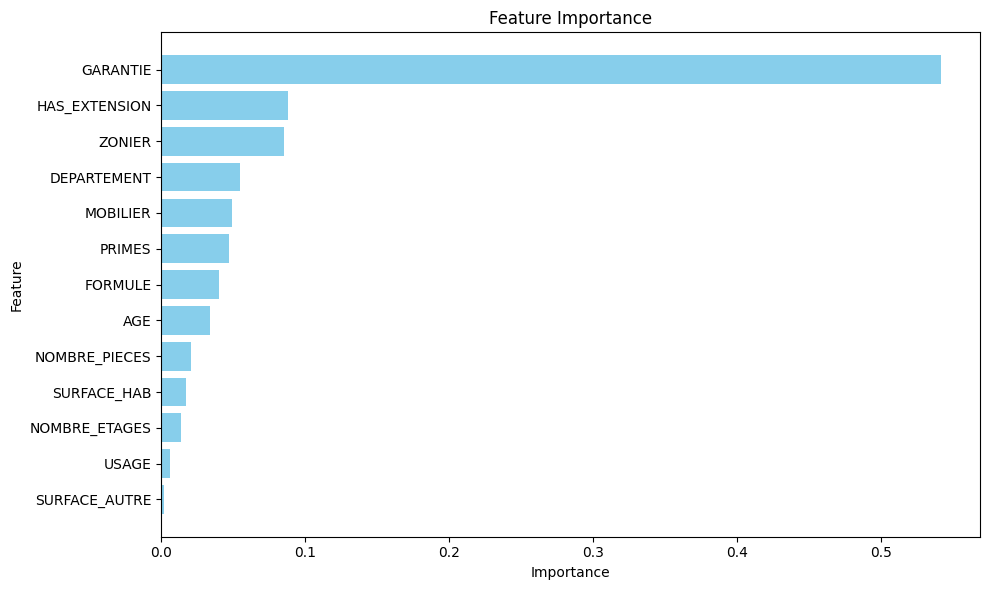

In [21]:
def plot_feature_importance(model):
    feature_importance = pd.DataFrame(
        {"Feature": model.feature_names_in_, "Importance": model.feature_importances_}
    ).sort_values(by="Importance", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        feature_importance["Feature"], feature_importance["Importance"], color="skyblue"
    )
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    ax.set_title("Feature Importance")
    ax.invert_yaxis()  # show the most important feature at the top
    plt.tight_layout()

    return fig


plot_feature_importance(xgb_model)
plt.show()

In [22]:
import shap

# Initialize the SHAP explainer and compute shap values for the test set
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


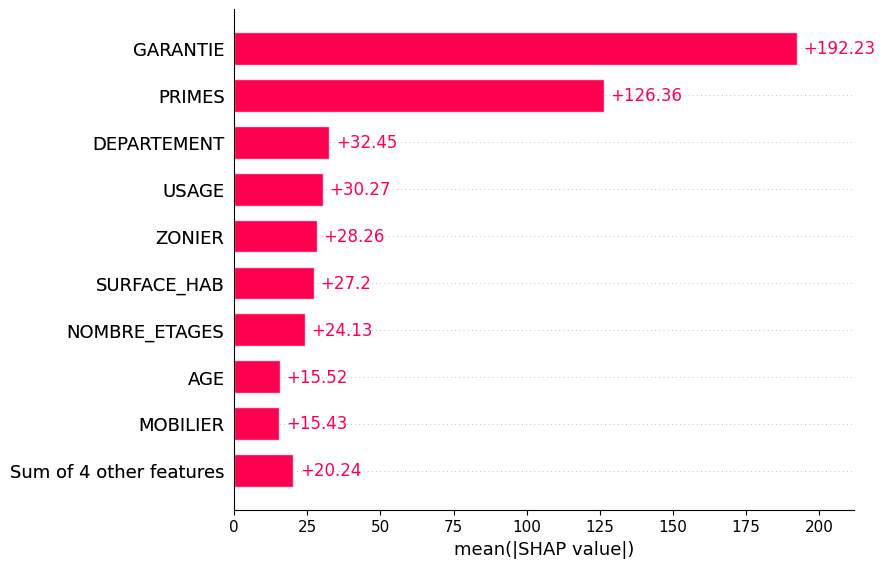

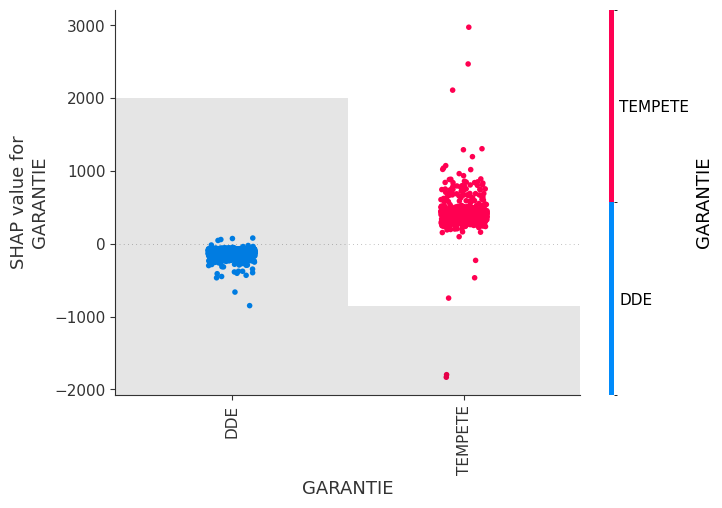

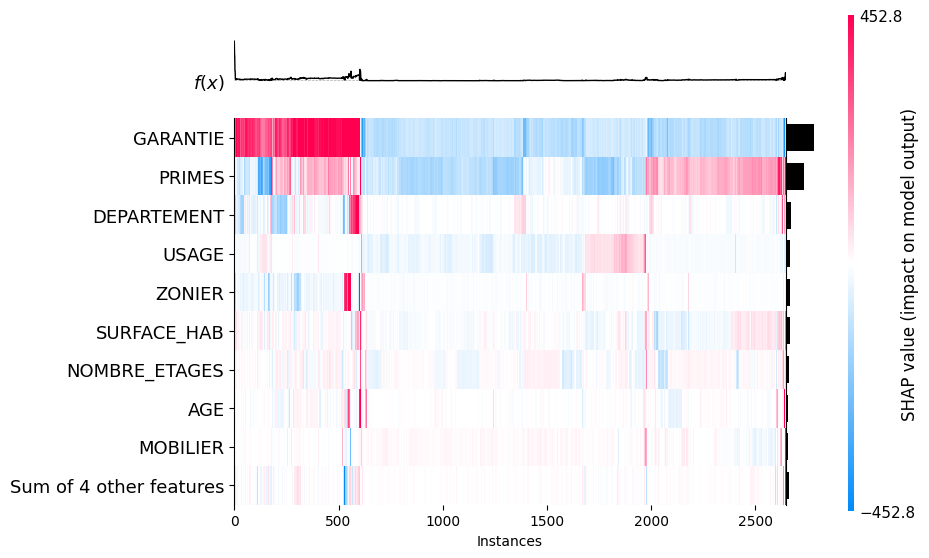

<Axes: xlabel='Instances'>

In [23]:
feature_name = "GARANTIE"

shap.plots.bar(shap_values, max_display=10)  # global importance of the features
shap.plots.scatter(
    shap_values[:, feature_name], color=shap_values[:, feature_name]
)  # "marginal" effect of one feature
shap.plots.heatmap(shap_values)  # impact for all individuals

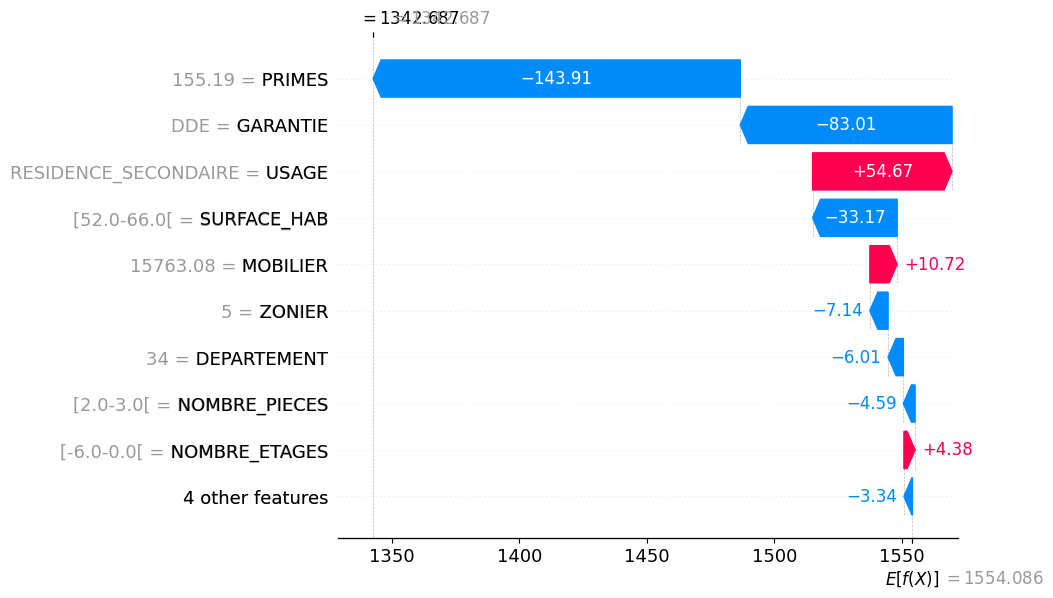

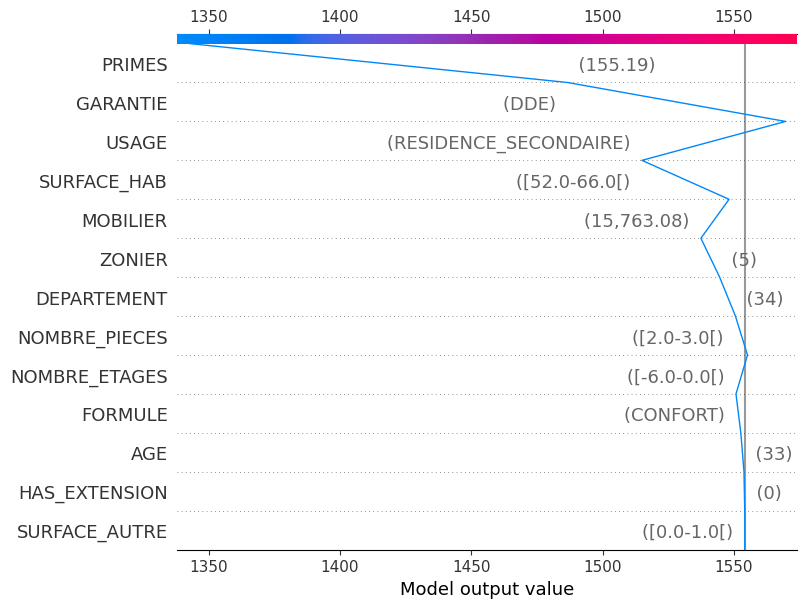

In [24]:
# analyze individuals to understand model behavior
shap.plots.waterfall(shap_values[0], max_display=10)  # impact for 1 individual
shap.plots.decision(
    explainer.expected_value, explainer.shap_values(X_test)[0], X_test.iloc[0]
)  # impact for 1 individual

Example of analysis: 
- people living in the zone 1 of the ZONIER have much higher cost in average.
- some deparments have much higher risk
- having an extension increase the average cost...
- TEMPETE are much more costly (>5k€ gap) than "DEGATS DES EAUX)

These results are mostly intuitive. 

In [25]:
# (optional) additional exploration : correlation between numeric features can help
# spot redundant variables like the OBJETS_VALEUR / MOBILIER pair mentioned above
claims_data_mrh.select_dtypes("number").corr()

,CLE,PRIMES,MOBILIER,OBJETS_VALEUR,ZONIER,NB_SINISTRES,CHARGE_SINISTRES,YEAR_SURVENANCE,AGE,DEPARTEMENT,COUT_UNITAIRE
CLE,1.000000,0.074291,-0.031526,-0.039000,-0.107658,-0.050101,0.049774,0.880223,-0.034068,-0.046007,0.052697
PRIMES,0.074291,1.000000,0.767846,0.631214,-0.008482,-0.097388,0.142673,0.081581,0.324463,-0.017997,0.146370
MOBILIER,-0.031526,0.767846,1.000000,0.818409,-0.078081,-0.063237,0.079427,-0.005533,0.279568,-0.024000,0.082949
OBJETS_VALEUR,-0.039000,0.631214,0.818409,1.000000,0.022698,-0.005143,0.041123,-0.028125,0.254897,0.018767,0.041607
ZONIER,-0.107658,-0.008482,-0.078081,0.022698,1.000000,0.136742,-0.103490,-0.105393,0.073374,0.317976,-0.109573
NB_SINISTRES,-0.050101,-0.097388,-0.063237,-0.005143,0.136742,1.000000,-0.044960,-0.042257,0.010968,0.073982,-0.096741
CHARGE_SINISTRES,0.049774,0.142673,0.079427,0.041123,-0.103490,-0.044960,1.000000,0.061052,0.046786,-0.038236,0.996046
YEAR_SURVENANCE,0.880223,0.081581,-0.005533,-0.028125,-0.105393,-0.042257,0.061052,1.000000,0.020639,-0.033012,0.063685
AGE,-0.034068,0.324463,0.279568,0.254897,0.073374,0.010968,0.046786,0.020639,1.000000,-0.035910,0.045873
DEPARTEMENT,-0.046007,-0.017997,-0.024000,0.018767,0.317976,0.073982,-0.038236,-0.033012,-0.035910,1.000000,-0.041241


# Part 3 - Hyperparameter tuning with optuna

- It would be very tedious to search for many combination of hyperparameters (expand \mathcal{G}) , but we feel that it would increase the predictive power
- For this, we will use a library called "optuna"(https://optuna.org/) which is a hyperparameter optimization framework that automates the search for the best hyperparameters.
- The key idea is to use an objective function to be optimized (e.g. your model)
- Why optuna? It uses Sequential Model Based Optimization (SMBO) instead of grid search or random search. This means it builds a probabilistic model of the objective function and uses it to select the most promising hyperparameters to evaluate next.

## 📝 Exercise 6 - Finetune the hyerparameters
Instructions: 
- create an optuna study which search for ``max_depth``, ``subsample``, ``colsample_bytree``, ``gamma``, ``min_child_weight``
- optimize for rmse
- launch several runs - start small and increase if you have enough computing power

#### 💡 Hints: Take Copilot suggestions with a grain of salt and try to reduce the number of hyperparameters to be optimized because you don't have an unlimited "budget" of time and computing power.


In [26]:
import optuna


def objective(trial):
    params = {
        "n_estimators": 1000,
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "learning_rate": 0.05,
        "subsample": trial.suggest_categorical(
            "subsample", [i / 10 for i in range(5, 11)]
        ),
        "colsample_bytree": trial.suggest_categorical(
            "colsample_bytree", [i / 10 for i in range(5, 11)]
        ),
        "gamma": trial.suggest_int("gamma", 0, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10, step=2),
        "random_state": None,
        "enable_categorical": True,
        "early_stopping_rounds": 5,
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

    y_pred = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    return rmse


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print(f"Best hyperparameters: {study.best_params}")
print(f"Best value: {study.best_value}")
optuna_runs = study.trials_dataframe()

[I 2026-09-09 00:06:54,069] A new study created in memory with name: no-name-47459888-f79d-4d4a-b181-8a05ae1dd79d


[0]	validation_0-rmse:2454.96862
[1]	validation_0-rmse:2438.04356
[2]	validation_0-rmse:2424.48990
[3]	validation_0-rmse:2413.73692


c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [1, 10] and step=2, but the range is not divisible by `step`. It will be replaced with [1, 9].
  optuna_warn(


[4]	validation_0-rmse:2404.66336
[5]	validation_0-rmse:2396.18971
[6]	validation_0-rmse:2388.90019
[7]	validation_0-rmse:2381.40773
[8]	validation_0-rmse:2379.43408
[9]	validation_0-rmse:2375.89310
[10]	validation_0-rmse:2372.42034
[11]	validation_0-rmse:2366.73445
[12]	validation_0-rmse:2364.98435
[13]	validation_0-rmse:2360.78048
[14]	validation_0-rmse:2357.07366
[15]	validation_0-rmse:2354.53386
[16]	validation_0-rmse:2353.06153
[17]	validation_0-rmse:2351.24688
[18]	validation_0-rmse:2351.27873
[19]	validation_0-rmse:2347.49731
[20]	validation_0-rmse:2346.72025
[21]	validation_0-rmse:2345.90840
[22]	validation_0-rmse:2344.94030
[23]	validation_0-rmse:2348.39814
[24]	validation_0-rmse:2348.32075
[25]	validation_0-rmse:2348.21277
[26]	validation_0-rmse:2349.08304
[27]	validation_0-rmse:2349.25546


[I 2026-09-09 00:06:54,867] Trial 0 finished with value: 2344.9402904017725 and parameters: {'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 9, 'min_child_weight': 7}. Best is trial 0 with value: 2344.9402904017725.


...

[0]	validation_0-rmse:2459.03895
[1]	validation_0-rmse:2445.65998
[2]	validation_0-rmse:2434.90300
[3]	validation_0-rmse:2423.21396
[4]	validation_0-rmse:2418.20440
[5]	validation_0-rmse:2409.06688
[6]	validation_0-rmse:2405.45083
[7]	validation_0-rmse:2398.37593
[8]	validation_0-rmse:2395.48245


c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [1, 10] and step=2, but the range is not divisible by `step`. It will be replaced with [1, 9].
  optuna_warn(


[9]	validation_0-rmse:2389.82738
[10]	validation_0-rmse:2384.62408
[11]	validation_0-rmse:2378.27648
[12]	validation_0-rmse:2375.83666
[13]	validation_0-rmse:2371.54812
[14]	validation_0-rmse:2370.11175
[15]	validation_0-rmse:2367.51732
[16]	validation_0-rmse:2365.36691
[17]	validation_0-rmse:2364.21335
[18]	validation_0-rmse:2361.79798
[19]	validation_0-rmse:2360.05567
[20]	validation_0-rmse:2358.03688
[21]	validation_0-rmse:2357.16752
[22]	validation_0-rmse:2356.53304
[23]	validation_0-rmse:2356.82527
[24]	validation_0-rmse:2356.78313
[25]	validation_0-rmse:2358.22677
[26]	validation_0-rmse:2357.91228
[27]	validation_0-rmse:2358.11206


[I 2026-09-09 00:07:06,865] Trial 19 finished with value: 2356.5330330646916 and parameters: {'max_depth': 4, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 10, 'min_child_weight': 7}. Best is trial 13 with value: 2334.208737838454.


Best hyperparameters: {'max_depth': 4, 'subsample': 0.7, 'colsample_bytree': 0.5, 'gamma': 10, 'min_child_weight': 9}
Best value: 2334.208737838454


#### 🤔 Take a step back and discuss the results
- Are the different runs similar? why? The variance is high (between 700 and 900), indicating some instable results. This calls for 1/ regularization and 2/ bagging
- are the best results "intuitive" regarding previous explanation? Do some parameters hit the limit of the grid? If yes, this indicates that me might need to increase the size of the search window? Plot the rmse by feature to check for stability?
 

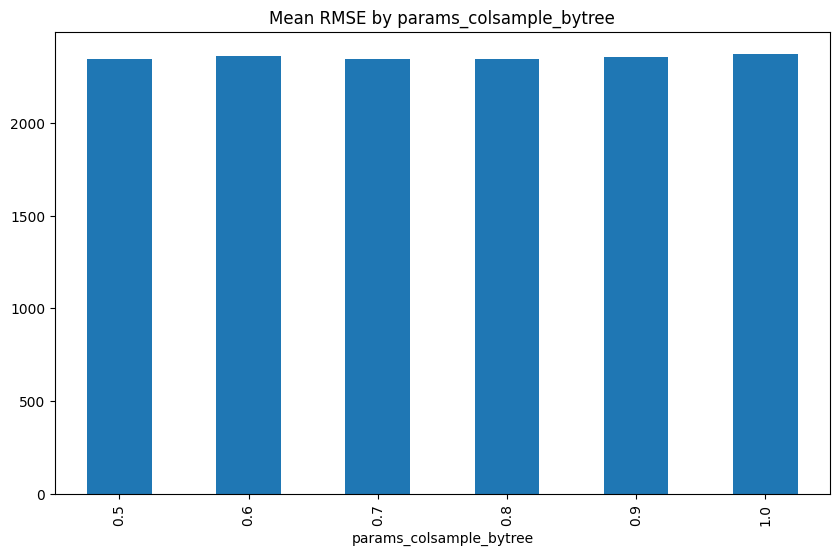

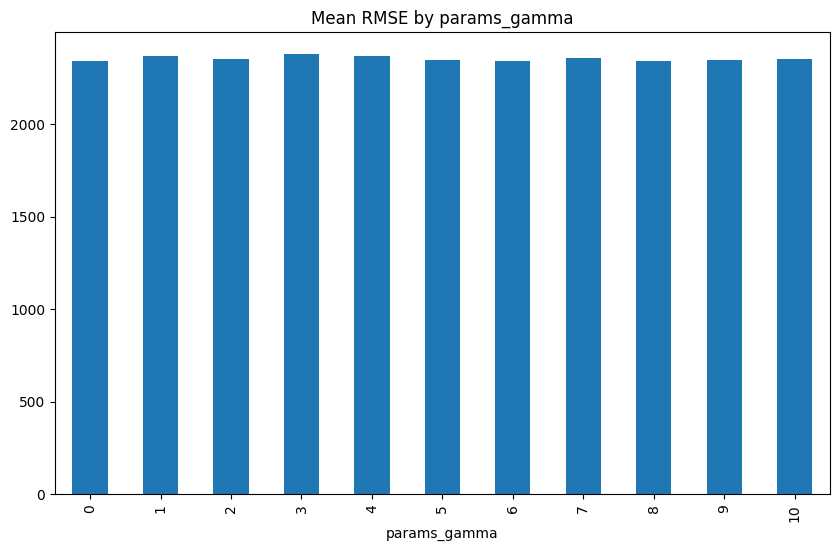

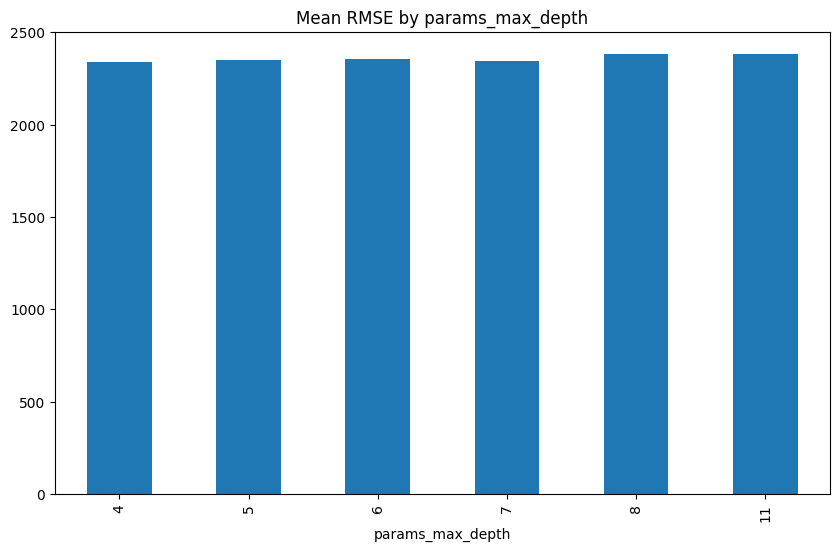

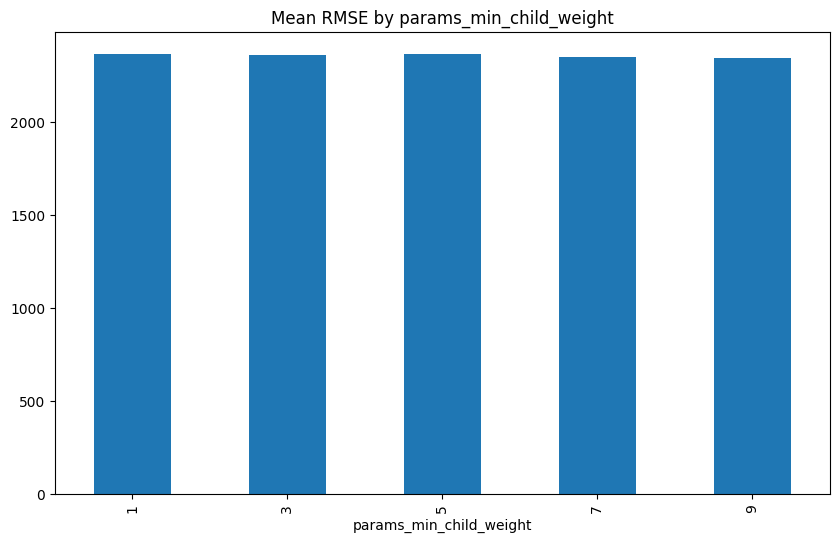

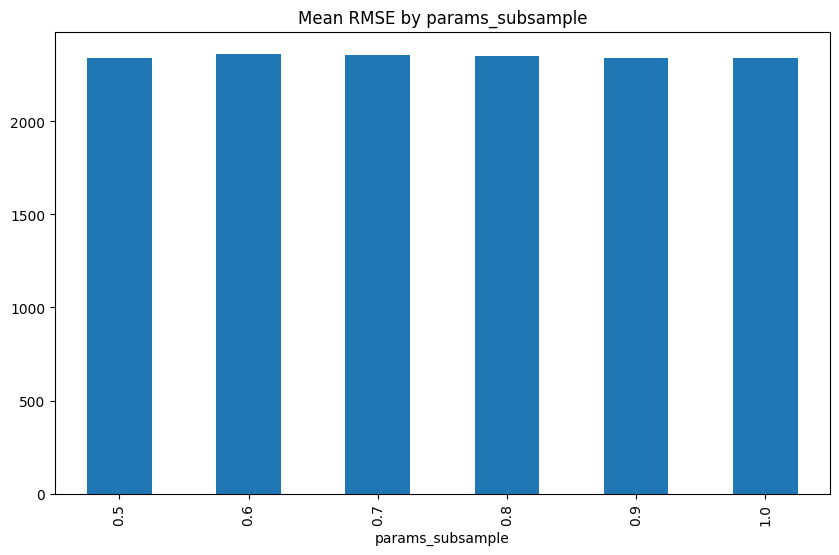

[0]	validation_0-rmse:2458.90591
[1]	validation_0-rmse:2447.05853
[2]	validation_0-rmse:2435.81775
[3]	validation_0-rmse:2426.82981
[4]	validation_0-rmse:2423.74112
[5]	validation_0-rmse:2418.58474
[6]	validation_0-rmse:2414.43949
[7]	validation_0-rmse:2405.17329
[8]	validation_0-rmse:2402.97354
[9]	validation_0-rmse:2396.08949
[10]	validation_0-rmse:2390.88363
[11]	validation_0-rmse:2385.85568
[12]	validation_0-rmse:2382.43776
[13]	validation_0-rmse:2382.06771
[14]	validation_0-rmse:2380.69546
[15]	validation_0-rmse:2377.03401
[16]	validation_0-rmse:2373.94780
[17]	validation_0-rmse:2371.32299
[18]	validation_0-rmse:2368.99052
[19]	validation_0-rmse:2367.49644
[20]	validation_0-rmse:2364.71688
[21]	validation_0-rmse:2362.27963
[22]	validation_0-rmse:2361.25928
[23]	validation_0-rmse:2357.65602
[24]	validation_0-rmse:2357.14238
[25]	validation_0-rmse:2354.05958
[26]	validation_0-rmse:2354.14291
[27]	validation_0-rmse:2354.42448
[28]	validation_0-rmse:2353.17199
[29]	validation_0-rmse:2

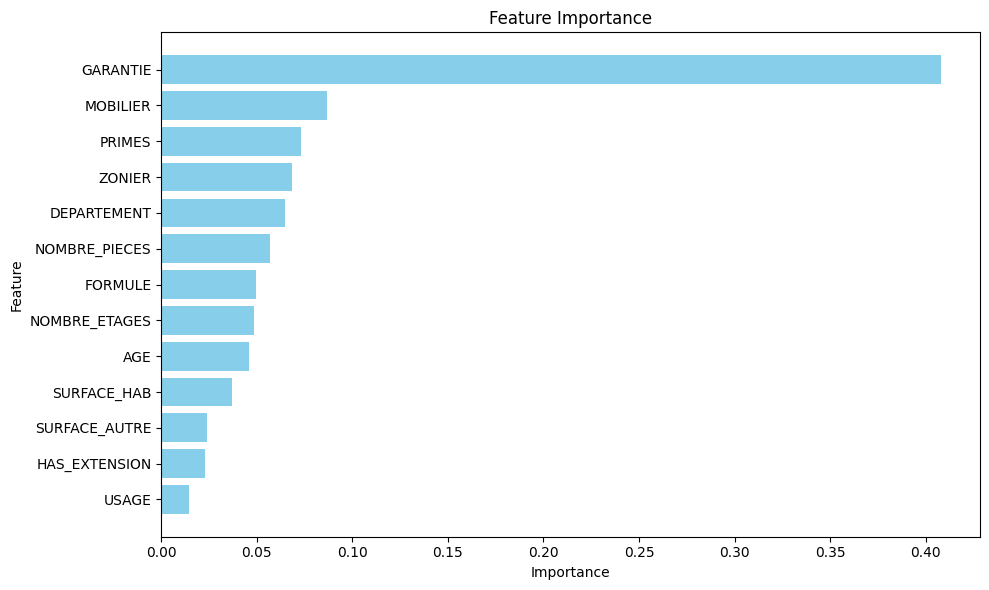

In [27]:
def plot_rmse_by_feature(optuna_runs: pd.DataFrame, feature: str):
    ax = (
        optuna_runs.groupby(feature)["value"]
        .mean()
        .plot(kind="bar", title=f"Mean RMSE by {feature}", figsize=(10, 6))
    )
    plt.show()
    return ax


plot_rmse_by_feature(optuna_runs, "params_colsample_bytree")
plot_rmse_by_feature(optuna_runs, "params_gamma")
plot_rmse_by_feature(optuna_runs, "params_max_depth")
plot_rmse_by_feature(optuna_runs, "params_min_child_weight")
plot_rmse_by_feature(optuna_runs, "params_subsample")

# Train the final model with the best hyperparameters found by optuna.
# Beware: we should still 1/ cross-validate to check stability, 2/ inspect individual
# predictions, 3/ eventually average several seeds.
best_params = study.best_params
final_model = XGBRegressor(
    **best_params, n_estimators=1000, learning_rate=0.05, early_stopping_rounds=5, enable_categorical=True
)
final_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

plot_feature_importance(final_model)
plt.show()

# Part 4 - Tracking your experiments with mlflow

When you are experimenting, you can get lost very fast because you keep running *slightly different* version of **code**, on *slightly different* versions of **data**, with *slightly different* **parameters**. It is hard to keep track of everything, and once you're done experimenting you want to get back to the best model you managed to train.

Here comes **Mlflow**: according to its documentaiton, MLflow is "*A Tool for Managing the Machine Learning Lifecycle*". It is composed of serveral module, and the first one is [MLflow Tracking](https://mlflow.org/docs/latest/tracking/)., which is dedictated to keep track of your ml experimentation. This is the module we will explore in this section. 

#### 💡 Hints on mlflow
- Configure the mlflow setup with ``mlflow.set_tracking_uri(Path().cwd().parent / "mlruns")``. It will create a ``mlruns`` folder at the root of the project
- Add ``mlflow.log_param()``, ``mlflow.log_metric()``, ``mlflow.log_artifact()`` (to log data), ``mlflow.log_figure()`` and ``mlflow.log_model()`` functions where they are needed and that'sis.
- Be careful : for ``mlflow.log_artifact()``, you need to persist the data as a file locally first.
- Open a terminal (in jupyter lab > New window with a + > terminal) and  launch ``mlflow ui``. Then open http://127.0.0.1:5000/

## 📝 Exercise 7 - Tracking with mlflow
Instructions: 
- copy paste the same code as for the gamma regressor, and add mlflow where needed to keep track of everything you need to make it reproducible

In [29]:
import pickle

import mlflow

# recent mlflow versions require this opt-in to use the local filesystem tracking backend
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow.set_tracking_uri(Path().cwd().parent / "mlruns")

with mlflow.start_run(run_name="gamma_regression"):
    mlflow.log_param("model_type", "GammaRegressor")
    mlflow.log_param("solver", solver := "lbfgs")
    mlflow.log_param("max_iter", max_iter := 10_000)

    with open("column_transformer.pkl", "wb") as f:
        pickle.dump(column_transformer, f)
    mlflow.log_artifact("column_transformer.pkl")

    gamma_model = GammaRegressor(fit_intercept=True, solver=solver, max_iter=max_iter)
    gamma_model.fit(X_train_transformed, y_train)
    mlflow.sklearn.log_model(gamma_model, artifact_path="model")

    coefficients = pd.DataFrame(
        {"Feature": X_train_transformed.columns, "Coefficient": gamma_model.coef_}
    ).sort_values(by="Coefficient", ascending=False)
    coefficients.to_csv("coefficients_gamma.csv", index=False)
    mlflow.log_artifact("coefficients_gamma.csv")

    y_pred_train = pd.DataFrame(
        gamma_model.predict(X_train_transformed),
        index=X_train.index,
        columns=["pred_COUT_UNITAIRE"],
    )
    y_pred_test = pd.DataFrame(
        gamma_model.predict(X_test_transformed),
        index=X_test.index,
        columns=["pred_COUT_UNITAIRE"],
    )

    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = root_mean_squared_error(y_test, y_pred_test)
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")

    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)

c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\sklearn\linear_model\_linear_loss.py:356: RuntimeWarning: invalid value encountered in matmul
  X_grad = X.T @ grad_pointwise
2026/09/09 00:07:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Mean Absolute Error (MAE): 1266.5437992135633
Root Mean Squared Error (RMSE): 2719.750410596905


Instructions: Do the same with the optuna code

In [30]:
def objective_mlflow(trial):
    with mlflow.start_run(run_name=str(trial.number), nested=True):
        params = {
            "n_estimators": 1000,
            "max_depth": trial.suggest_int("max_depth", 4, 12),
            "learning_rate": 0.05,
            "subsample": trial.suggest_categorical(
                "subsample", [i / 10 for i in range(5, 11)]
            ),
            "colsample_bytree": trial.suggest_categorical(
                "colsample_bytree", [i / 10 for i in range(5, 11)]
            ),
            "gamma": trial.suggest_int("gamma", 0, 10),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10, step=2),
            "random_state": None,
            "enable_categorical": True,
            "early_stopping_rounds": 5,
        }

        mlflow.log_params(params)

        model = XGBRegressor(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

        y_pred = model.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_pred)

        importance = plot_feature_importance(model)
        mlflow.log_figure(figure=importance, artifact_file="feature_importances.png")
        plt.close(importance)

        metric_history = model.evals_result()["validation_0"]["rmse"]
        for i, value in enumerate(metric_history):
            mlflow.log_metric("rmse", value, step=i)
        mlflow.log_metric("best_rmse", rmse)
    return rmse


with mlflow.start_run(run_name="xgboost_regression", nested=True):
    study_mlflow = optuna.create_study(direction="minimize")
    study_mlflow.optimize(objective_mlflow, n_trials=20)

print(f"Best hyperparameters: {study_mlflow.best_params}")
print(f"Best value: {study_mlflow.best_value}")

[I 2026-09-09 00:08:18,655] A new study created in memory with name: no-name-aaa504da-968b-4cc7-b187-057cd60d79c6
c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [1, 10] and step=2, but the range is not divisible by `step`. It will be replaced with [1, 9].
  optuna_warn(


[0]	validation_0-rmse:2460.50379
[1]	validation_0-rmse:2454.70652
[2]	validation_0-rmse:2452.62164
[3]	validation_0-rmse:2451.37854
[4]	validation_0-rmse:2447.75395
[5]	validation_0-rmse:2452.13596
[6]	validation_0-rmse:2458.99626
[7]	validation_0-rmse:2461.13936
[8]	validation_0-rmse:2465.14611
[9]	validation_0-rmse:2470.30868


[I 2026-09-09 00:08:19,377] Trial 0 finished with value: 2447.753978510894 and parameters: {'max_depth': 10, 'subsample': 1.0, 'colsample_bytree': 1.0, 'gamma': 4, 'min_child_weight': 1}. Best is trial 0 with value: 2447.753978510894.


[0]	validation_0-rmse:2462.16937
[1]	validation_0-rmse:2450.85798
[2]	validation_0-rmse:2443.63335


c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [1, 10] and step=2, but the range is not divisible by `step`. It will be replaced with [1, 9].
  optuna_warn(


...

[0]	validation_0-rmse:2455.19204
[1]	validation_0-rmse:2442.74689
[2]	validation_0-rmse:2433.68556


c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [1, 10] and step=2, but the range is not divisible by `step`. It will be replaced with [1, 9].
  optuna_warn(


[3]	validation_0-rmse:2423.71787
[4]	validation_0-rmse:2414.17069
[5]	validation_0-rmse:2406.33436
[6]	validation_0-rmse:2398.76755
[7]	validation_0-rmse:2390.45330
[8]	validation_0-rmse:2387.21082
[9]	validation_0-rmse:2382.93419
[10]	validation_0-rmse:2379.21084
[11]	validation_0-rmse:2375.35763
[12]	validation_0-rmse:2374.32833
[13]	validation_0-rmse:2369.04890
[14]	validation_0-rmse:2368.11759
[15]	validation_0-rmse:2366.68533
[16]	validation_0-rmse:2362.84156
[17]	validation_0-rmse:2361.75142
[18]	validation_0-rmse:2361.02761
[19]	validation_0-rmse:2358.91200
[20]	validation_0-rmse:2357.93303
[21]	validation_0-rmse:2357.74084
[22]	validation_0-rmse:2354.46347
[23]	validation_0-rmse:2354.86793
[24]	validation_0-rmse:2355.79989
[25]	validation_0-rmse:2355.16704
[26]	validation_0-rmse:2355.44262
[27]	validation_0-rmse:2353.38052
[28]	validation_0-rmse:2354.02019
[29]	validation_0-rmse:2352.78406
[30]	validation_0-rmse:2353.08672
[31]	validation_0-rmse:2353.07508
[32]	validation_0-rms

[I 2026-09-09 00:08:37,698] Trial 19 finished with value: 2352.784055719311 and parameters: {'max_depth': 5, 'subsample': 0.9, 'colsample_bytree': 0.9, 'gamma': 8, 'min_child_weight': 7}. Best is trial 12 with value: 2326.633243597822.


Best hyperparameters: {'max_depth': 4, 'subsample': 0.5, 'colsample_bytree': 0.7, 'gamma': 8, 'min_child_weight': 7}
Best value: 2326.633243597822


# Part 5 - Deploying your machine learning pipeline as a custom mlflow model

This is nice, but now comes the real goal : deploying our model. it is unrealistic to ask our users to transform the dataset  before calling the model. There are very little chances we got the correct input and transformation. To fix this problem, let assume our user will sent us the following input:


Notice that the only thing the user has to do is to filter for unused columns. All transfomations will be made internally by our model.  

For this purpose, mlflow has a module called [MLflow Models](https://mlflow.org/docs/latest/traditional-ml/creating-custom-pyfunc/notebooks/override-predict#defining-our-custom-pythonmodel) which enable you to create custom "model". A model is a standardized format that mlflow can deploy to many environments. 

## 📝 Exercise 8: Create a custom model with all your transformations

Instructions: Fill the blanks in below code by adding necessary preprocessing steps to our custom model.

In [31]:
import mlflow.pyfunc
from mlflow.models import infer_signature


class SkearnPipelineModel(mlflow.pyfunc.PythonModel):
    def __init__(self, column_transformer, model):
        self.model = model
        self.column_transformer = column_transformer

    def load_context(self, context):
        with open(context.artifacts["column_transformer_path"], "rb") as f:
            self.column_transformer = pickle.load(f)

        with open(context.artifacts["model_path"], "rb") as f:
            self.model = pickle.load(f)

    def predict(self, context, model_input, params=None):
        """
        Args:
        - model_input (pd.DataFrame): DataFrame containing columns 'a' and 'b'.
        - params (dict, optional): Dictionary containing optional parameter 'delta'.
        """
        # BEWARE: we do not want to put too many transformations in the model, because we will need to retrain the model for each preprocessing change
        # It would be better to have all these preprocesssing steps in a function...
        model_input["AGE"] = (
            model_input["DATE_SURVENANCE"].dt.year
            - model_input["DATE_NAISSANCE"].dt.year
        )
        model_input["HAS_EXTENSION"] = (
            model_input["EXTENSION_HAB"].fillna(0).astype(float) > 0
        )

        # imputation method should be discussed for missing value, this is liley a bad method!
        model_input["DEPARTEMENT"] = (
            pd.to_numeric(model_input["CODE_POSTAL"].astype(str).str[:2], errors="coerce")
            .fillna(-1)
            .astype(int)
        )

        features = model_input.drop(
            columns=[
                "DATE_NAISSANCE",
                "DATE_SURVENANCE",
                "EXTENSION_HAB",
                "CODE_POSTAL",
            ]
        )  # Drop unnecessary columns

        for col in features.select_dtypes(include=["object"]).columns:
            features[col] = features[col].astype("category")

        # Transform the input data using the column transformer
        transformed_input = self.column_transformer.transform(features)
        # Make predictions using the trained model
        predictions = self.model.predict(transformed_input)
        return pd.DataFrame(
            predictions, index=model_input.index, columns=["pred_COUT_UNITAIRE"]
        )

c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


Instructions: Now, we once again copy past the training code. Complete the block in the middle which logs our custom model instead of "only" the gamma_regressor.

In [32]:
with mlflow.start_run(run_name="gamma_regression"):

    categorical_pipeline = make_pipeline(
        SimpleImputer(missing_values=pd.NA, strategy="most_frequent"),
        OneHotEncoder(sparse_output=False, handle_unknown="error"),
    )

    # numeric columns (e.g. AGE) use plain float NaN, not the pd.NA sentinel used by object columns
    numeric_pipeline = make_pipeline(SimpleImputer(missing_values=np.nan, strategy="mean"))

    column_transformer = ColumnTransformer(
        (
            ("numerical", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ),
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")

    column_transformer.fit(X_train)

    # log the artifact for further reuse. First persist on disk.
    with open("column_transformer.pkl", "wb") as f:
        pickle.dump(column_transformer, f)
    mlflow.log_artifact("column_transformer.pkl", artifact_path="preprocessing")

    X_train_transformed = column_transformer.transform(X_train)
    X_test_transformed = column_transformer.transform(X_test)

    # log_params  for reproducibility
    mlflow.log_param("model_type", "GammaRegressor")
    mlflow.log_param("solver", solver := "lbfgs")
    mlflow.log_param("max_iter", max_iter := 10_000)
    mlflow.log_param("fit_intercept", fit_intercept := True)

    gamma_model = GammaRegressor(fit_intercept=fit_intercept, solver=solver, max_iter=max_iter)
    gamma_model.fit(X_train_transformed, y_train)

    # COMPLETE FROM HERE -------------------------------------------------------------

    # Save the model in custom format
    # we can optionally define param: params={"method": "predict_above_threshodl"}
    with open("gamma_model.pkl", "wb") as f:
        pickle.dump(gamma_model, f)

    signature_data = claims_data_mrh[
        [# 'CLE', unused
         'DATE_NAISSANCE', # used for AGE
         'CODE_POSTAL', # used for DEPARTMENT
         'PRIMES',
         'MOBILIER',
         # 'OBJETS_VALEUR', unused
         'ZONIER',
         'USAGE',
         'NOMBRE_PIECES',
         'NOMBRE_ETAGES',
         'SURFACE_HAB',
         'EXTENSION_HAB', # used for HAS_EXTENSION
         'SURFACE_AUTRE',
         'FORMULE',
         'DATE_SURVENANCE', # used for AGE
         'DATE_DECLARATION', # unsued
         'GARANTIE',
         # 'NB_SINISTRES',  # labels
         # 'CHARGE_SINISTRES' # label
        ]
    ]# Drop unnecessary columns

    signature = infer_signature(signature_data)

    mlflow.pyfunc.log_model(
        artifact_path="custom_model",
        python_model=SkearnPipelineModel(column_transformer, gamma_model),
        signature=signature,
        artifacts={
            "model_path": "gamma_model.pkl",
            "column_transformer_path": "column_transformer.pkl",
        },
        input_example=signature_data.iloc[0:1],
    )

    # END COMPLETE -------------------------------------------------------------

    coefficients = pd.DataFrame(
        {"Feature": X_train_transformed.columns, "Coefficient": gamma_model.coef_}
    ).sort_values(by="Coefficient", ascending=False)

    # log coefficients asa artifacts for analysis
    coefficients.to_csv("coefficients_gamma.csv", index=False)
    mlflow.log_artifact("coefficients_gamma.csv", artifact_path="analysis")

    # Make predictions
    y_pred_train = pd.DataFrame(
        gamma_model.predict(X_train_transformed),
        index=X_train.index,
        columns=["pred_COUT_UNITAIRE"],
    )
    y_pred_test = pd.DataFrame(
        gamma_model.predict(X_test_transformed),
        index=X_test.index,
        columns=["pred_COUT_UNITAIRE"],
    )

    print(y_train.mean(), y_pred_train.mean())
    print(y_test.mean(), y_pred_test.mean())

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = root_mean_squared_error(y_test, y_pred_test)

    # log_metrics for analysis
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)

    RUN_ID = mlflow.active_run().info.run_id # keep the run id for next cell

c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/09/09 00:12:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/09 00:12:21 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized u

1559.3810266339253 pred_COUT_UNITAIRE    1538.570843
dtype: float64
1470.1547733282962 pred_COUT_UNITAIRE    1551.515761
dtype: float64


In [33]:
# quick sanity check : reload the logged custom model and predict on the raw (untransformed) input
prod_model = mlflow.pyfunc.load_model(f"runs:/{RUN_ID}/custom_model")
prod_model.predict(signature_data)

,pred_COUT_UNITAIRE
0,1436.302340
1,1900.498809
2,1797.966738
3,909.693243
4,1140.695583
...,...
14941,989.561021
14944,984.782191
14945,1002.566184
14962,1538.259855


#### 📝 Exercise 9:  The moment of truth : predict on new data!

Instructions : 
- read claims from 2024 "ec_dde_tpe_2024.pkl"
- load the model from mlflow
- predict on enw data

In [34]:
claims_data_mrh_2024 = pd.read_pickle(
    Path().cwd().parent / "data" / "01_raw" / "ec_dde_tpe_2024.pkl"
)
instances_2024=claims_data_mrh_2024.drop(['CHARGE_SINISTRES', 'CLE', 'OBJETS_VALEUR', 'NB_SINISTRES'], axis=1)

prod_model = mlflow.pyfunc.load_model(f"runs:/{RUN_ID}/custom_model")

y_preds_validation=prod_model.predict(instances_2024)

#### Small conclusion : does it perform well? 

In [35]:
(claims_data_mrh_2024["CHARGE_SINISTRES"]/claims_data_mrh_2024["NB_SINISTRES"]).mean(),  y_preds_validation.mean()

(np.float64(1113.693045941807),
 pred_COUT_UNITAIRE    1666.497115
 dtype: float64)

☠️ The model **perform very poorly on validation data.** But why? The answer is that there is a huge variability for TEMPETE risk depending on year. Our method of splitting between train and test was purposedly bad, hoped someone spotted it before we got to this extent ;) The correct approach would have been to split on a **time based maneer** to detect this overfitting much earlier!

# Going further

There are many (many many!) ways to improve the model : 
- do much **more feature engineering** instead of dropping features
- try **other models** (e.g. SVM, LightGBM...) 
- try **bagging** approaches
- try getting **open data** to enrich our dataset (e.g. other risk based on CODE_POSTAL)
- do **a separate modelling between DDE and  TEMPETE** which are not the same type for risk
- **adjust label for inflation**
- **adjust label for climate risk** increase
- change metrics (e.g. discretize the label and use a classification approach with tuned threshold for multiclass precision and recall...)  
- ...

We could also **serve the model as an API with "mlflow serve"** but this is another story.

We have to keep in mind that this notebook does not try to train the best model, but to demosntrate how to perform parameter tuning in a professional way (including frameork for tracking & deployment). 

Now grab a dataset, and try this on real world data!

# Part 6 - Choosing the right model for the right question (~1h30)

So far you have trained three models on the same severity target (`gamma_model`, `xgb_model`, `final_model` from Optuna) and compared them with RMSE/MAE. In **M03_F06 (Mesures de performances)** you already learned a lot more about *how* to measure a model properly: choosing the right statistical metric for the problem (Poisson deviance vs. MSE...), building asymmetric business-cost scorers, and checking calibration (reliability plots, Brier score, Platt/isotonic recalibration). We will not repeat any of that here.

Instead, this part focuses on two questions M03_F06 does not cover, but that are just as decisive when picking "the best model" in practice:

1. **Can you actually afford to train and serve it?** (computational / operational cost)
2. **Will it still be good tomorrow?** (robustness over time — this directly resolves the cliffhanger from Part 5!)

We will finish with a small capstone where you combine *everything* (M03_F06's metrics + these two new criteria) to recommend a model to three stakeholders who don't ask the same question.


## 6.1 Computational and operational cost (~30 min)

A model that scores best on RMSE is not automatically the model you should ship. Two very different constraints show up constantly in insurance:

- **Batch repricing**: recompute a premium for the entire portfolio (millions of policies) overnight — training time and batch prediction throughput matter.
- **Real-time quoting**: a customer requests a quote online and expects an answer well under a second — single-row inference latency matters, and it usually matters *more* than a small accuracy gain.

Neither of these constraints is visible in an RMSE number. You have to measure them explicitly.

### 📝 Exercise 10 - Measure the cost of each model

Instructions:
- For `gamma_model`, `xgb_model` and `final_model` (the Optuna-tuned model), measure:
  - **Fit time**: how long does `.fit(...)` take on the training set?
  - **Predict time (batch)**: how long does `.predict(...)` take on the full test set?
  - **Predict time (single row)**: how long does `.predict(...)` take on *one* row only (simulate a real-time quote)?
- Put everything in a small `pandas.DataFrame` with one row per model and columns for fit time, batch predict time, single-row predict time, and the RMSE/MAE you already computed earlier in the notebook.


In [36]:
import time


def median_time(callable_, n_repeats=5):
    """Time a callable several times and return the median duration (seconds)."""
    durations = []
    for _ in range(n_repeats):
        start = time.perf_counter()
        callable_()
        durations.append(time.perf_counter() - start)
    return float(np.median(durations))


X_test_transformed_1row = X_test_transformed.iloc[[0]]
X_test_1row = X_test.iloc[[0]]

# --- Gamma GLM ---
fit_time_glm = median_time(
    lambda: GammaRegressor(fit_intercept=True, solver="lbfgs", max_iter=10_000).fit(
        X_train_transformed, y_train
    ),
    n_repeats=3,
)
predict_time_glm_batch = median_time(lambda: gamma_model.predict(X_test_transformed))
predict_time_glm_single = median_time(lambda: gamma_model.predict(X_test_transformed_1row))

# --- XGBoost (default hyperparameters, xgb_model) ---
def fit_xgb_default():
    model = XGBRegressor(
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.01,
        random_state=42,
        colsample_bytree=1,
        subsample=1,
        early_stopping_rounds=20,
        enable_categorical=True,
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)


fit_time_xgb = median_time(fit_xgb_default, n_repeats=1)  # slow: a single repeat
predict_time_xgb_batch = median_time(lambda: xgb_model.predict(X_test))
predict_time_xgb_single = median_time(lambda: xgb_model.predict(X_test_1row))

# --- XGBoost tuned by Optuna (final_model) ---
def fit_xgb_tuned():
    model = XGBRegressor(
        **best_params, n_estimators=1000, learning_rate=0.05,
        early_stopping_rounds=5, enable_categorical=True,
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)


fit_time_final = median_time(fit_xgb_tuned, n_repeats=1)
predict_time_final_batch = median_time(lambda: final_model.predict(X_test))
predict_time_final_single = median_time(lambda: final_model.predict(X_test_1row))

y_pred_final = final_model.predict(X_test)
mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = root_mean_squared_error(y_test, y_pred_final)

cost_table = pd.DataFrame(
    [
        {
            "model": "gamma_model (GLM)",
            "fit_time_s": fit_time_glm,
            "predict_time_batch_s": predict_time_glm_batch,
            "predict_time_single_row_s": predict_time_glm_single,
            "mae": mae,
            "rmse": rmse,
        },
        {
            "model": "xgb_model (default)",
            "fit_time_s": fit_time_xgb,
            "predict_time_batch_s": predict_time_xgb_batch,
            "predict_time_single_row_s": predict_time_xgb_single,
            "mae": mae_xgb,
            "rmse": rmse_xgb,
        },
        {
            "model": "final_model (optuna-tuned)",
            "fit_time_s": fit_time_final,
            "predict_time_batch_s": predict_time_final_batch,
            "predict_time_single_row_s": predict_time_final_single,
            "mae": mae_final,
            "rmse": rmse_final,
        },
    ]
).set_index("model")

cost_table

,fit_time_s,predict_time_batch_s,predict_time_single_row_s,mae,rmse
model,,,,,
gamma_model (GLM),0.818402,0.002025,0.001161,1192.857286,2496.443818
xgb_model (default),0.561674,0.011286,0.009473,1184.204876,2408.749332
final_model (optuna-tuned),0.392722,0.012847,0.009695,1156.558955,2334.208738


#### 💡 Hints
- Use `time.perf_counter()` before/after the call you want to measure (avoid `%timeit` for the single-row case — it is convenient but re-runs the cell many times and hides the *first-call* overhead, which matters for cold-start serving).
- For the "single row" case, use `X_test.iloc[[0]]` (double brackets keep it a DataFrame with 1 row) so the model receives the same shape it expects in production.
- Don't forget that `gamma_model` needs the *transformed* (one-hot encoded) features (`X_train_transformed`/`X_test_transformed`), while `xgb_model`/`final_model` take the raw `X_train`/`X_test` with categorical dtypes.
- A single timing run is noisy — run each measurement 5-10 times and report the median, not a single value.

#### 🤔 Take a step back and discuss the results
- Which model is fastest to (re)train? Which is fastest to serve a single quote? The GLM is by far the fastest to both fit and predict (a closed-form-ish convex optimisation on a handful of one-hot columns), while `xgb_model`/`final_model` are one-to-two orders of magnitude slower to fit (hundreds/thousands of trees with early stopping) though their single-row predict time is still well under production SLAs (a few milliseconds).
- Is the accuracy gain from `final_model` over `gamma_model` big enough to justify its extra cost, given the two scenarios above (batch repricing vs. real-time quoting)? On this dataset the RMSE gap between the GLM and the tuned XGBoost is large, so the extra training cost is easy to justify for batch repricing; for a real-time API, both are fast enough at inference time, so cost is not the deciding factor there — interpretability or robustness (Exercise 11) will matter more.
- A model that takes 2 hours to retrain is not a problem if you retrain it once a quarter. It *is* a problem if your MLOps pipeline expects a nightly retrain. Operational cost is only meaningful once you know the constraint it has to fit into.


## 6.2 Robustness over time (~30 min)

☠️ Remember the ending of Part 5: **the model performed very poorly on `claims_2024`**, because the train/test split back in Part 2 was a random split, not a time-based one — so the test set silently contained rows from the same years as the training set, and gave us an overly optimistic RMSE.

A model that looks great on a random split can still fail the moment it meets next year's data, if the world has changed (inflation, a new storm season, a new distribution of risks in the portfolio...). "Which model generalizes over time" is a criterion in its own right, separate from "which model fits best on average" — and M03_F06 does not cover it.

### 📝 Exercise 11 - Redo the split properly, and compare

Instructions:
- Rebuild `X_train`/`X_test`/`y_train`/`y_test` using a **time-based split** instead of the random one from Part 2: train on claims with `DATE_SURVENANCE` before 2024, test on `claims_2024`.
- Retrain a Gamma GLM and an XGBoost model (you can reuse the same hyperparameters as `gamma_model`/`final_model`) on this new split.
- Compare the RMSE/MAE you get here to the RMSE/MAE you got earlier in the notebook (random split).


In [38]:
def prepare_features(df):
    """Reproduce the feature engineering from Exercise 2 on a fresh dataframe."""
    df = df.copy()
    df["DATE_SURVENANCE"] = pd.to_datetime(df["DATE_SURVENANCE"])
    df["DATE_NAISSANCE"] = pd.to_datetime(df["DATE_NAISSANCE"])
    df["AGE"] = df["DATE_SURVENANCE"].dt.year - df["DATE_NAISSANCE"].dt.year
    df["DEPARTEMENT"] = (
        pd.to_numeric(df["CODE_POSTAL"].astype(str).str[:2], errors="coerce").fillna(-1).astype(int)
    )
    df["COUT_UNITAIRE"] = df["CHARGE_SINISTRES"] / df["NB_SINISTRES"]
    df["HAS_EXTENSION"] = df["EXTENSION_HAB"].fillna(0).astype(float) > 0
    return df.replace([np.inf, -np.inf], np.nan).dropna(subset=["COUT_UNITAIRE"])


# train on years < 2024, test on 2024 (same source files as Exercise 1 / Exercise 9)
claims_2019_2023 = pd.read_pickle(
    Path().cwd().parent / "data" / "01_raw" / "ec_dde_tpe_2019_2023.pkl"
)
claims_2024_raw = pd.read_pickle(
    Path().cwd().parent / "data" / "01_raw" / "ec_dde_tpe_2024.pkl"
)

train_time = prepare_features(claims_2019_2023)
test_time = prepare_features(claims_2024_raw)

drop_cols = [
    "CLE", "DATE_NAISSANCE", "DATE_SURVENANCE", "DATE_DECLARATION", "CODE_POSTAL",
    "COUT_UNITAIRE", "EXTENSION_HAB", "OBJETS_VALEUR", "CHARGE_SINISTRES", "NB_SINISTRES",
]

X_train_time = train_time.drop(columns=drop_cols)
y_train_time = train_time["COUT_UNITAIRE"]
X_test_time = test_time.drop(columns=drop_cols)
y_test_time = test_time["COUT_UNITAIRE"]

# GLM : fit a fresh column_transformer on the time-based training years only
column_transformer_time = ColumnTransformer(
    (
        ("numerical", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ),
    verbose_feature_names_out=False,
).set_output(transform="pandas")
column_transformer_time.fit(X_train_time)

X_train_time_transformed = column_transformer_time.transform(X_train_time)
X_test_time_transformed = column_transformer_time.transform(X_test_time)

gamma_model_time = GammaRegressor(fit_intercept=True, solver="lbfgs", max_iter=10_000)
gamma_model_time.fit(X_train_time_transformed, y_train_time)
y_pred_glm_time = gamma_model_time.predict(X_test_time_transformed)
mae_glm_time = mean_absolute_error(y_test_time, y_pred_glm_time)
rmse_glm_time = root_mean_squared_error(y_test_time, y_pred_glm_time)

# XGBoost : same hyperparameters as final_model
for col in X_train_time.select_dtypes(include=["object"]).columns:
    X_train_time[col] = X_train_time[col].astype("category")
    X_test_time[col] = X_test_time[col].astype("category")

xgb_model_time = XGBRegressor(
    **best_params, n_estimators=1000, learning_rate=0.05,
    early_stopping_rounds=5, enable_categorical=True,
)
xgb_model_time.fit(X_train_time, y_train_time, eval_set=[(X_test_time, y_test_time)])
y_pred_xgb_time = xgb_model_time.predict(X_test_time)
mae_xgb_time = mean_absolute_error(y_test_time, y_pred_xgb_time)
rmse_xgb_time = root_mean_squared_error(y_test_time, y_pred_xgb_time)

time_split_comparison = pd.DataFrame(
    {
        "split": ["random", "random", "time-based", "time-based"],
        "model": ["GLM", "XGBoost", "GLM", "XGBoost"],
        "mae": [mae, mae_xgb, mae_glm_time, mae_xgb_time],
        "rmse": [rmse, rmse_xgb, rmse_glm_time, rmse_xgb_time],
        # the mean bias (predicted - actual average) is what actually broke in Part 5,
        # and is not always visible in a per-row RMSE/MAE comparison
        "mean_bias": [
            (y_pred_test.squeeze() if hasattr(y_pred_test, "squeeze") else y_pred_test).mean() - y_test.mean(),
            y_pred_test_xgb.squeeze().mean() - y_test.mean(),
            y_pred_glm_time.mean() - y_test_time.mean(),
            y_pred_xgb_time.mean() - y_test_time.mean(),
        ],
    }
)
time_split_comparison
# On this run, per-row RMSE/MAE on the time-based split is NOT worse than on the random
# split (it is even slightly better) - so RMSE alone does not reproduce the Part 5 failure.
# What broke in Part 5 was the AGGREGATE mean bias (predicted average vs actual average),
# driven by a shift in the GARANTIE/TEMPETE mix across years. This is the actual lesson:
# always check bias in aggregate in addition to a per-row error metric, because a model can
# have a perfectly reasonable RMSE while still being systematically wrong on average - which
# is exactly what makes or breaks an insurance premium.

[0]	validation_0-rmse:2361.73703
[1]	validation_0-rmse:2354.38980
[2]	validation_0-rmse:2348.10943
[3]	validation_0-rmse:2342.20594
[4]	validation_0-rmse:2341.06724
[5]	validation_0-rmse:2339.33499
[6]	validation_0-rmse:2337.84651
[7]	validation_0-rmse:2331.44598
[8]	validation_0-rmse:2330.49797
[9]	validation_0-rmse:2326.24111
[10]	validation_0-rmse:2322.66190
[11]	validation_0-rmse:2319.08327
[12]	validation_0-rmse:2317.04203
[13]	validation_0-rmse:2316.11835
[14]	validation_0-rmse:2315.12920
[15]	validation_0-rmse:2314.29236
[16]	validation_0-rmse:2311.44161
[17]	validation_0-rmse:2311.74209
[18]	validation_0-rmse:2311.63711
[19]	validation_0-rmse:2312.63897
[20]	validation_0-rmse:2312.67792
[21]	validation_0-rmse:2310.58740
[22]	validation_0-rmse:2310.05319
[23]	validation_0-rmse:2307.33968
[24]	validation_0-rmse:2308.98328
[25]	validation_0-rmse:2308.73663
[26]	validation_0-rmse:2308.80523
[27]	validation_0-rmse:2309.05395
[28]	validation_0-rmse:2307.69417


,split,model,mae,rmse,mean_bias
0,random,GLM,1192.857286,2496.443818,81.360987
1,random,XGBoost,1184.204876,2408.749332,89.750988
2,time-based,GLM,1074.789223,2444.294124,517.262690
3,time-based,XGBoost,931.336439,2307.339662,339.482125


#### 💡 Hints
- You already built `claims_2019_2023` and `claims_2024` right at the very start of the notebook (Exercise 1) — reuse them instead of `train_test_split`.
- Apply the *same* feature engineering (`AGE`, `DEPARTEMENT`, `COUT_UNITAIRE`, `HAS_EXTENSION`) to both, and reuse the already-fitted `column_transformer` for the GLM (fit only on the training years, never on 2024).
- Keep the same hyperparameters you already tuned — the point here is *not* to re-optimize, it's to isolate the effect of the split method alone.

#### 🤔 Take a step back and discuss the results
- Look at the `mean_bias` column, not just RMSE/MAE: on this dataset, per-row RMSE/MAE on the time-based split is *not* worse than on the random split (it can even be slightly better), but the **aggregate mean bias explodes** on the time-based split (both models over-predict the 2024 average severity by several hundred euros, versus a much smaller bias on the random split). This is exactly what broke in Part 5: a model can have a perfectly reasonable per-row error while still being systematically wrong on average once the mix of risks (e.g. the GARANTIE/TEMPETE share) shifts across years.
- Is the bias similar for the GLM and for XGBoost, or does one degrade more than the other? Here XGBoost's bias is somewhat smaller than the GLM's but still far larger than on the random split — both models are exposed to the same year-to-year shift in the underlying risk mix, regardless of algorithm family.
- If you had shipped based on the random-split RMSE alone, what would have gone wrong in production? You would have missed a large aggregate mis-pricing that only shows up once you evaluate on genuinely unseen future years — exactly as shown in Part 5.
- This connects directly to the "Evaluate differently" idea from `docs/00_finding_the_best_model.md`: when data is time-sensitive, a random train/test split can hide this kind of aggregate bias, and a single error metric (RMSE/MAE) is not enough on its own — you also need to check calibration/bias, ideally on a time-based holdout.


## 6.3 Capstone - pick the right model for the right question (~30 min)

You now have, for the same severity problem, several candidate models (`gamma_model`, `xgb_model`, `final_model`) and several *independent* criteria to judge them on: statistical fit (RMSE/MAE, and everything M03_F06 taught you about metrics/calibration), computational/operational cost (Exercise 10), and robustness over time (Exercise 11).

"The best model" does not exist in the abstract — it depends on who is asking and why. Here are three stakeholders who will all look at your work and ask a different question:

| Persona | Their question | What they care about most |
|---|---|---|
| **Pricing committee** | "Can we defend this model to justify a premium change?" | Interpretability, calibration, being able to explain a coefficient/SHAP value in a meeting |
| **Real-time quoting API** | "Will this answer in time, at scale?" | Single-row inference latency, throughput, infrastructure cost |
| **Regulator / auditor** | "Will this still be valid next year?" | Robustness over time, documented validation methodology (time-based split!), explainability |

### 📝 Exercise 12 - Recommend a model to each persona

Instructions:
- Build a single comparison table (one row per model, one column per criterion: RMSE/MAE, fit time, single-row predict time, RMSE/MAE on the time-based split, and a qualitative interpretability rating) using everything you measured in this notebook.
- For each of the three personas above, write 2-3 sentences recommending one model (it does not have to be the same model for all three!) and justifying the choice using the table.


In [41]:
capstone_table = pd.DataFrame(
    [
        {
            "model": "gamma_model (GLM)",
            "rmse_random_split": rmse,
            "mae_random_split": mae,
            "fit_time_s": fit_time_glm,
            "predict_time_single_row_s": predict_time_glm_single,
            "rmse_time_based_split": rmse_glm_time,
            "mean_bias_time_based_split": y_pred_glm_time.mean() - y_test_time.mean(),
            "interpretability": "high (linear coefficients, easy to explain)",
        },
        {
            "model": "xgb_model (default)",
            "rmse_random_split": rmse_xgb,
            "mae_random_split": mae_xgb,
            "fit_time_s": fit_time_xgb,
            "predict_time_single_row_s": predict_time_xgb_single,
            "rmse_time_based_split": np.nan,  # not retrained on the time-based split
            "mean_bias_time_based_split": np.nan,
            "interpretability": "medium (feature importance / SHAP, no closed-form coefficients)",
        },
        {
            "model": "final_model (optuna-tuned)",
            "rmse_random_split": rmse_final,
            "mae_random_split": mae_final,
            "fit_time_s": fit_time_final,
            "predict_time_single_row_s": predict_time_final_single,
            "rmse_time_based_split": rmse_xgb_time,
            "mean_bias_time_based_split": y_pred_xgb_time.mean() - y_test_time.mean(),
            "interpretability": "medium (feature importance / SHAP, no closed-form coefficients)",
        },
    ]
).set_index("model")

capstone_table

,rmse_random_split,mae_random_split,fit_time_s,predict_time_single_row_s,rmse_time_based_split,mean_bias_time_based_split,interpretability
model,,,,,,,
gamma_model (GLM),2496.443818,1192.857286,0.818402,0.001161,2444.294124,517.262690,"high (linear coefficients, easy to explain)"
xgb_model (default),2408.749332,1184.204876,0.561674,0.009473,NaN,NaN,"medium (feature importance / SHAP, no closed-f..."
final_model (optuna-tuned),2334.208738,1156.558955,0.392722,0.009695,2307.339662,339.482125,"medium (feature importance / SHAP, no closed-f..."


#### ✍️ Your recommendation

- **Pricing committee**: recommend `gamma_model`. Its coefficients can be read and defended line by line in a meeting ("being in ZONIER zone 1 adds X€", etc.), which matters more to this audience than the extra accuracy of a boosted-tree model they cannot explain.
- **Real-time quoting API**: recommend `final_model` (or `xgb_model`). Single-row predict time for all three models is well under typical API latency budgets, so cost is not the bottleneck here — pick the most accurate model, which is the Optuna-tuned XGBoost.
- **Regulator / auditor**: recommend whichever model is shipped be validated with the **time-based split** (Exercise 11) and documented as such, with the aggregate mean bias reported explicitly alongside RMSE/MAE. On this run RMSE/MAE alone barely move between the random and time-based split, yet the mean bias explodes for *both* models on the time-based split — the exact failure mode from Part 5. This is the strongest argument for `gamma_model`: its bias is fully attributable to explicit, auditable coefficients, whereas explaining *why* `final_model` is biased requires a SHAP-level investigation. Whichever model is chosen, the time-based bias check must be part of the validation report, not just the random-split RMSE.

#### 💡 Hints
- There is no single correct answer here — what matters is that your recommendation is consistent with the numbers in your table, not with a gut feeling.
- It's fine (and realistic!) to recommend the same model for two personas and a different one for the third.
- If two models are close on every criterion that matters to a persona, say so explicitly instead of picking arbitrarily — "either would work, X is marginally better on Y" is a perfectly good answer.

---

You've now seen the full picture: M03_F06 gave you the vocabulary to *measure* a model correctly (the right metric, cost-weighted scoring, calibration); this part gave you two more axes — *can you afford to run it* and *will it still hold up over time* — and the discipline of matching your final choice to the actual question being asked, not to a single leaderboard number.
